# Phase 3: Cultural Norm Robustness Analysis
**Models**: Tiny-Aya (Global/Fire/Earth/Water), Qwen3.5 (0.8B/2B/9B/9B-R), Gemma-4-31B (NR/R), Command-a (NR/R)

**Countries**: India (Hindi), Turkey (Turkish), Vietnam (Vietnamese)

**Perturbation Conditions**:
- **Language conditions**: EN, EN_PARA, LOCAL (Hindi/Turkish/Vietnamese), LOCAL_PARA, MISMATCH
- **Context conditions**: NONE, COUNTRY, VALUES, RULES
- **Conflict conditions**: NONE, WRONG_RULES, WRONG_COUNTRY, MADE_UP

In [1]:
import warnings; warnings.filterwarnings("ignore", category=FutureWarning)
from pathlib import Path
import importlib
import numpy as np, pandas as pd, matplotlib.pyplot as plt, matplotlib.ticker as mtick, seaborn as sns
import analysis_helpers; importlib.reload(analysis_helpers)
from analysis_helpers import *

WORKDIR = Path.cwd()
OUT = WORKDIR / "final_analysis_outputs"
PLOTS = OUT / "plots"; PLOTS.mkdir(parents=True, exist_ok=True)
PAPER = OUT / "paper"; PAPER.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="paper")
PAL = ["#1B4965","#2A9D8F","#E9C46A","#D1495B","#577590","#F4A261","#7A9E7E","#6D597A"]
sns.set_palette(PAL)
sns.set_context("paper", font_scale=1.4)
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 12,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "axes.spines.top": False,
    "axes.spines.right": False
})


In [2]:
paths = sorted((WORKDIR / "final_results").glob("aggregated_all_models_*.csv"))
assert len(paths) == 3, f"Expected 3 CSVs, found {len(paths)}"
raw_runs_all = load_runs(paths, WORKDIR)

# NaN prediction == unparseable / error / empty after normalize_label
UNPARSEABLE_VALUES = {"unparseable", "error", ""}

def is_unparseable(label) -> bool:
    if label is None:
        return True
    return str(label).strip().lower() in UNPARSEABLE_VALUES

unparseable_mask = raw_runs_all["prediction"].isna()
raw_runs_unp     = raw_runs_all[unparseable_mask].copy()
raw_runs         = raw_runs_all[~unparseable_mask].copy()

# Parse-rate breakdown
print("=== Data Quality / Parse Rate Breakdown ===")
total_all = len(raw_runs_all)
total_val = len(raw_runs)
total_unp = len(raw_runs_unp)
print(f"Total Raw Runs:  {total_all:,}")
print(f"Valid Parsed:    {total_val:,} ({total_val/total_all*100:.1f}%)")
print(f"Unparseable:     {total_unp:,} ({total_unp/total_all*100:.1f}%)\n")

print("--- Model Parse Rates ---")
model_parse_rate = raw_runs_all.groupby("model").apply(lambda x: (~x["prediction"].isna()).mean()).sort_values(ascending=False)
for m, r in model_parse_rate.items():
    print(f"  {m:30s} {r*100:.1f}%")

results = aggregate(raw_runs)
print(f"\nFinal Aggregated Conditions: {len(results):,}")
print(f"Models: {sorted(results['model'].unique())}")
print(f"Countries: {sorted(results['country'].unique())}")
print(f"Language conditions: {sorted(results['lang_condition'].unique())}")

=== Data Quality / Parse Rate Breakdown ===
Total Raw Runs:  55,000
Valid Parsed:    53,927 (98.0%)
Unparseable:     1,073 (2.0%)

--- Model Parse Rates ---
  Command-a                      100.0%
  Command-a-Reasoning            100.0%
  Earth                          100.0%
  Fire                           100.0%
  Global                         100.0%
  Qwen3.5-0.8B                   100.0%
  Qwen3.5-2B                     100.0%
  Qwen3.5-9B                     100.0%
  Water                          100.0%
  Gemma-4-31B-Reasoning          95.3%
  Gemma-4-31B                    94.1%
  Qwen3.5-9B-Reasoning           91.1%



Final Aggregated Conditions: 10,966
Models: ['Command-a', 'Command-a-Reasoning', 'Earth', 'Fire', 'Gemma-4-31B', 'Gemma-4-31B-Reasoning', 'Global', 'Qwen3.5-0.8B', 'Qwen3.5-2B', 'Qwen3.5-9B', 'Qwen3.5-9B-Reasoning', 'Water']
Countries: ['India', 'Turkey', 'Vietnam']
Language conditions: ['EN', 'EN_PARA', 'LOCAL', 'LOCAL_PARA', 'MISMATCH']


## 1. Overall Model Accuracy Ranking

In [3]:
acc_overall = results.groupby("model")["accuracy"].mean().reindex(MODEL_ORDER).dropna().sort_values(ascending=False)
print("=== Overall Model Ranking ===")
for i,(m,a) in enumerate(acc_overall.items(), 1):
    print(f"  {i}. {m:30s} {a*100:.1f}%")

=== Overall Model Ranking ===
  1. Command-a-Reasoning            64.0%
  2. Gemma-4-31B                    59.9%
  3. Command-a                      59.6%
  4. Gemma-4-31B-Reasoning          59.6%
  5. Qwen3.5-9B-Reasoning           59.5%
  6. Qwen3.5-9B                     59.5%
  7. Water                          56.3%
  8. Qwen3.5-2B                     52.4%
  9. Global                         51.2%
  10. Earth                          49.1%
  11. Qwen3.5-0.8B                   45.3%
  12. Fire                           42.0%


## 2. Accuracy by Language Condition (per model)
EN/EN_PARA = English, LOCAL/LOCAL_PARA = local language (Hindi/Turkish/Vietnamese), MISMATCH = unrelated language

In [4]:
acc_by_cond = (results.groupby(["model","lang_condition"])["accuracy"].mean().unstack("lang_condition")
    .reindex(index=MODEL_ORDER).reindex(columns=LANG_CONDITION_ORDER).dropna(how="all"))
print("=== Accuracy (%) by Model × Language Condition ===")
print((acc_by_cond*100).round(1).to_string())

print("\n=== Best Model per Language Condition ===")
for cond in LANG_CONDITION_ORDER:
    if cond in acc_by_cond.columns:
        best = acc_by_cond[cond].idxmax()
        print(f"  {cond:12s} → {best:30s} ({acc_by_cond.loc[best,cond]*100:.1f}%)")

=== Accuracy (%) by Model × Language Condition ===
lang_condition           EN  EN_PARA  LOCAL  LOCAL_PARA  MISMATCH
model                                                            
Global                 54.9     43.0   44.0        43.0      49.0
Fire                   43.3     34.5   44.8        34.5      44.8
Earth                  50.6     40.0   48.6        54.3      42.9
Water                  60.7     55.6   41.7        52.8      44.4
Qwen3.5-0.8B           49.0     45.0   36.0        37.0      37.0
Qwen3.5-2B             55.4     42.0   49.0        48.0      49.0
Qwen3.5-9B             61.7     58.0   53.0        55.0      56.0
Qwen3.5-9B-Reasoning   61.3     59.0   57.0        55.0      55.0
Gemma-4-31B            59.9     59.0   59.6        60.0      61.0
Gemma-4-31B-Reasoning  59.6     59.0   60.0        59.0      60.0
Command-a              59.6     60.0   61.0        60.0      58.0
Command-a-Reasoning    62.7     66.0   65.0        67.0      67.0

=== Best Model per Langu

## 3. Accuracy by Actual Language (per country)
Since LOCAL maps to different languages per country, this breaks down
accuracy by the actual language used.

In [5]:
print("=== Accuracy by Actual Language (Country × Condition → Language) ===\n")
for country in COUNTRY_ORDER:
    c_df = results[results["country"]==country]
    print(f"  {country} (local language = {COUNTRY_LOCAL_LANG[country]}):")
    for cond in LANG_CONDITION_ORDER:
        sub = c_df[c_df["lang_condition"]==cond]
        if sub.empty: continue
        actual = resolve_language(country, cond)
        acc = sub["accuracy"].mean()
        print(f"    {cond:12s} ({actual:20s})  acc={acc*100:.1f}%  n={len(sub)}")
    print()

=== Accuracy by Actual Language (Country × Condition → Language) ===

  India (local language = Hindi):
    EN           (English             )  acc=53.5%  n=2017
    EN_PARA      (English (para)      )  acc=50.3%  n=290
    LOCAL        (Hindi               )  acc=51.0%  n=290
    LOCAL_PARA   (Hindi (para)        )  acc=46.9%  n=290
    MISMATCH     (Mismatch            )  acc=54.5%  n=290

  Turkey (local language = Turkish):
    EN           (English             )  acc=58.9%  n=2442
    EN_PARA      (English (para)      )  acc=52.0%  n=350
    LOCAL        (Turkish             )  acc=52.6%  n=350
    LOCAL_PARA   (Turkish (para)      )  acc=53.1%  n=350
    MISMATCH     (Mismatch            )  acc=51.1%  n=350

  Vietnam (local language = Vietnamese):
    EN           (English             )  acc=59.6%  n=2508
    EN_PARA      (English (para)      )  acc=57.5%  n=360
    LOCAL        (Vietnamese          )  acc=54.9%  n=359
    LOCAL_PARA   (Vietnamese (para)   )  acc=58.3%  n=360
 

## 4. Model Performance Ranking per Country

In [6]:
print("=== Model Ranking per Country ===")
for country in COUNTRY_ORDER:
    c_acc = (results[results["country"]==country].groupby("model")["accuracy"].mean()
        .reindex(MODEL_ORDER).dropna().sort_values(ascending=False))
    print(f"\n  {country} (local: {COUNTRY_LOCAL_LANG[country]}):")
    for i,(m,a) in enumerate(c_acc.items(), 1):
        print(f"    {i}. {m:30s} {a*100:.1f}%")

=== Model Ranking per Country ===

  India (local: Hindi):
    1. Command-a-Reasoning            63.3%
    2. Qwen3.5-9B-Reasoning           59.6%
    3. Command-a                      56.1%
    4. Gemma-4-31B                    55.7%
    5. Gemma-4-31B-Reasoning          55.3%
    6. Qwen3.5-9B                     54.9%
    7. Qwen3.5-0.8B                   48.3%
    8. Global                         46.1%
    9. Qwen3.5-2B                     43.9%
    10. Fire                           42.0%

  Turkey (local: Turkish):
    1. Command-a-Reasoning            64.2%
    2. Gemma-4-31B                    61.3%
    3. Gemma-4-31B-Reasoning          60.6%
    4. Command-a                      59.2%
    5. Qwen3.5-9B                     57.4%
    6. Qwen3.5-9B-Reasoning           56.8%
    7. Qwen3.5-2B                     55.6%
    8. Global                         51.2%
    9. Qwen3.5-0.8B                   49.6%
    10. Earth                          49.1%

  Vietnam (local: Vietnamese):

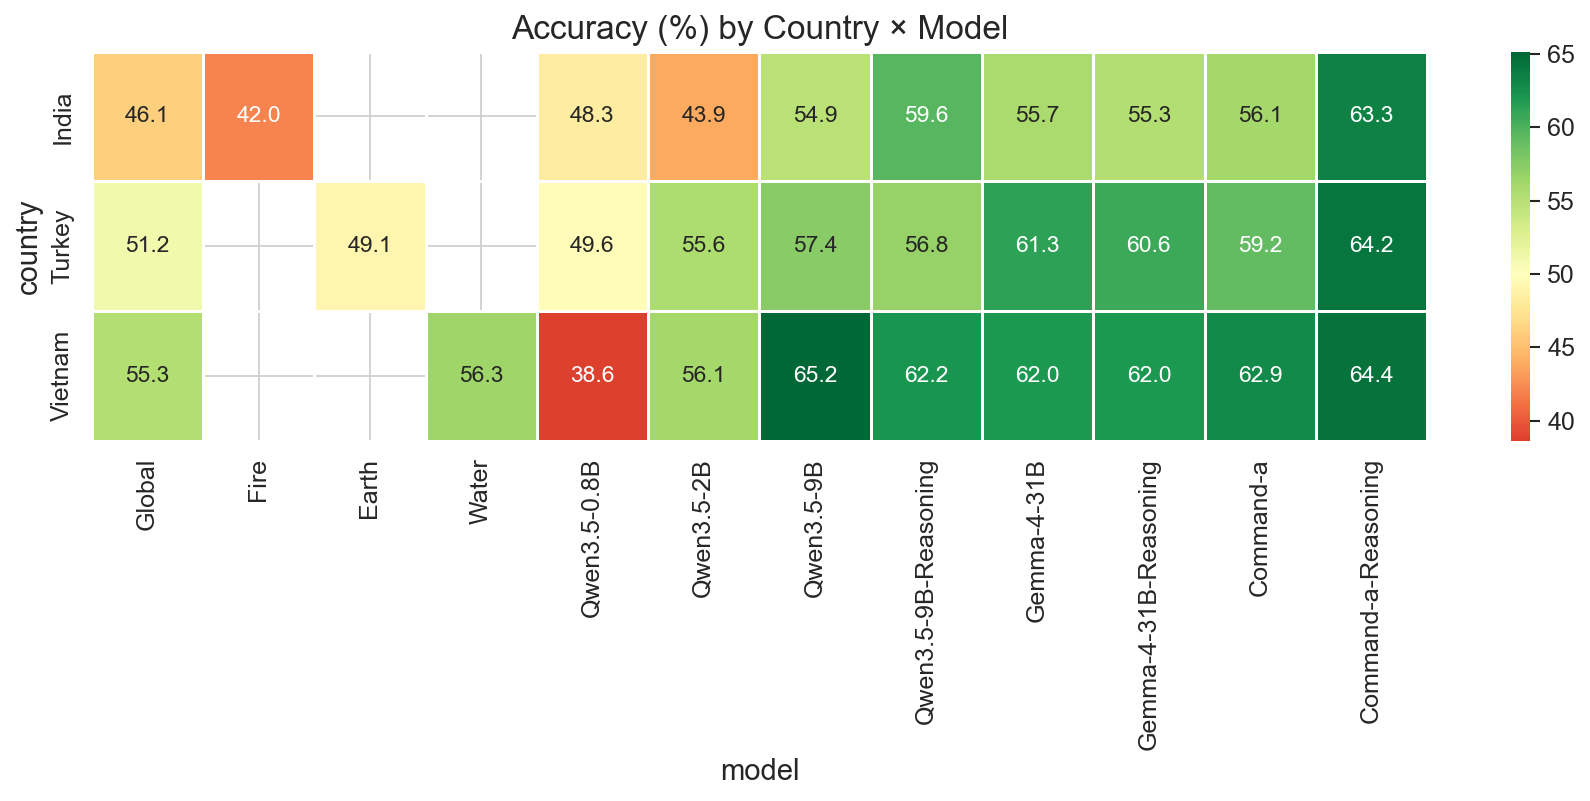

In [7]:
acc_hm = (results.groupby(["country","model"])["accuracy"].mean().unstack("model")
    .reindex(index=COUNTRY_ORDER).reindex(columns=MODEL_ORDER).dropna(axis=1, how="all"))
fig, ax = plt.subplots(figsize=(12,5.5))
sns.heatmap(acc_hm*100, annot=True, annot_kws={"size": 11}, fmt=".1f", cmap="RdYlGn", center=50, linewidths=.5, ax=ax)
ax.set_title("Accuracy (%) by Country × Model"); plt.tight_layout()
plt.savefig(PLOTS/"accuracy_heatmap.png", bbox_inches="tight"); plt.show(); plt.close()


## 5. Language Condition Robustness (Paired Comparisons)
These compare predictions under different language conditions
(e.g., EN vs LOCAL = English vs Hindi/Turkish/Vietnamese).

In [8]:
lang_comps = [
    ("EN","EN_PARA","EN → EN paraphrase"),
    ("EN","LOCAL","EN → Local language"),
    ("LOCAL","LOCAL_PARA","Local → Local paraphrase"),
    ("EN","LOCAL_PARA","EN → Local paraphrase"),
    ("EN","MISMATCH","EN → Mismatched language"),
    ("LOCAL","MISMATCH","Local → Mismatched language"),
]
lang_filters = {"context_type":"COUNTRY","conflict_type":"NONE"}
lang_pairs = {}
for l,r,desc in lang_comps:
    if {l,r}.issubset(results["lang_condition"].unique()):
        lang_pairs[desc] = build_pairs(results, LANGCOND_PAIR_IDX, "lang_condition", l, r, PAIR_VCOLS, lang_filters)

lang_summary = pd.concat([
    summarize_pairs(p).assign(comparison=k) for k,p in lang_pairs.items()
], ignore_index=True).sort_values("flip_rate", ascending=False)
print("=== Language Condition Robustness ===")
for _,r in lang_summary.iterrows():
    print(f"  {r.comparison:30s}  flip={r.flip_rate*100:.1f}%  Δacc={r.acc_delta*100:+.1f}pp  C2W={r.c2w_rate*100:.1f}%  W2C={r.w2c_rate*100:.1f}%")

=== Language Condition Robustness ===
  EN → Mismatched language        flip=15.6%  Δacc=+0.7pp  C2W=4.0%  W2C=4.7%
  Local → Mismatched language     flip=14.8%  Δacc=+0.6pp  C2W=3.7%  W2C=4.3%
  EN → Local paraphrase           flip=14.6%  Δacc=+0.3pp  C2W=4.5%  W2C=4.8%
  EN → Local language             flip=13.0%  Δacc=+0.0pp  C2W=4.0%  W2C=4.0%
  EN → EN paraphrase              flip=10.5%  Δacc=+0.6pp  C2W=2.0%  W2C=2.6%
  Local → Local paraphrase        flip=9.9%  Δacc=+0.2pp  C2W=2.8%  W2C=3.0%


In [9]:
print("\n=== Language Condition Flip Rate by Country ===")
print("(LOCAL = Hindi for India, Turkish for Turkey, Vietnamese for Vietnam)\n")
for k,p in lang_pairs.items():
    by_c = summarize_pairs(p, ["country"])
    if by_c.empty: continue
    print(f"  {k}:")
    for _,r in by_c.iterrows():
        print(f"    {r.country:10s}  flip={r.flip_rate*100:.1f}%  Δ={r.acc_delta*100:+.1f}pp  C2W={r.c2w_rate*100:.1f}%")
    print()


=== Language Condition Flip Rate by Country ===
(LOCAL = Hindi for India, Turkish for Turkey, Vietnamese for Vietnam)

  EN → EN paraphrase:
    India       flip=8.6%  Δ=-0.7pp  C2W=2.1%
    Turkey      flip=12.0%  Δ=+0.3pp  C2W=2.6%
    Vietnam     flip=10.6%  Δ=+1.9pp  C2W=1.4%

  EN → Local language:
    India       flip=11.4%  Δ=+0.0pp  C2W=4.1%
    Turkey      flip=17.7%  Δ=+0.9pp  C2W=5.1%
    Vietnam     flip=9.7%  Δ=-0.8pp  C2W=2.8%

  Local → Local paraphrase:
    India       flip=9.0%  Δ=-4.1pp  C2W=5.2%
    Turkey      flip=12.9%  Δ=+0.6pp  C2W=3.7%
    Vietnam     flip=7.8%  Δ=+3.3pp  C2W=0.0%

  EN → Local paraphrase:
    India       flip=14.1%  Δ=-4.1pp  C2W=6.9%
    Turkey      flip=17.7%  Δ=+1.4pp  C2W=5.4%
    Vietnam     flip=11.9%  Δ=+2.8pp  C2W=1.7%

  EN → Mismatched language:
    India       flip=13.8%  Δ=+3.4pp  C2W=2.1%
    Turkey      flip=18.0%  Δ=-0.6pp  C2W=6.3%
    Vietnam     flip=14.7%  Δ=-0.3pp  C2W=3.3%

  Local → Mismatched language:
    India       f

## 6. Reasoning vs Non-Reasoning (Within-Family)
Three paired comparisons: Command-a, Gemma-4-31B, Qwen3.5-9B

In [10]:
reason_pairs = {}
for l,r in REASONING_PAIRS:
    if {l,r}.issubset(results["model"].unique()):
        reason_pairs[f"{l} → {r}"] = build_pairs(results, MODEL_PAIR_IDX, "model", l, r, PAIR_VCOLS)

reason_summary = pd.concat([
    summarize_pairs(p).assign(comparison=k) for k,p in reason_pairs.items()
], ignore_index=True)
print("=== Reasoning Toggle: Overall ===")
for _,r in reason_summary.iterrows():
    print(f"  {r.comparison:40s}  flip={r.flip_rate*100:.1f}%  Δ={r.acc_delta*100:+.1f}pp  C2W={r.c2w_rate*100:.1f}%  W2C={r.w2c_rate*100:.1f}%")
    print(f"    {'':40s}  NR_acc={r.left_acc*100:.1f}%  R_acc={r.right_acc*100:.1f}%")

=== Reasoning Toggle: Overall ===
  Command-a → Command-a-Reasoning           flip=19.0%  Δ=+4.4pp  C2W=4.1%  W2C=8.5%
                                              NR_acc=59.6%  R_acc=64.0%
  Gemma-4-31B → Gemma-4-31B-Reasoning       flip=0.5%  Δ=-0.2pp  C2W=0.3%  W2C=0.1%
                                              NR_acc=59.9%  R_acc=59.7%
  Qwen3.5-9B → Qwen3.5-9B-Reasoning         flip=18.3%  Δ=-0.1pp  C2W=6.8%  W2C=6.7%
                                              NR_acc=59.6%  R_acc=59.5%


In [11]:
print("\n=== Reasoning Toggle by Country ===")
for k,p in reason_pairs.items():
    by_c = summarize_pairs(p, ["country"])
    print(f"\n  {k}:")
    for _,r in by_c.iterrows():
        print(f"    {r.country:10s}  flip={r.flip_rate*100:.1f}%  Δ={r.acc_delta*100:+.1f}pp  NR={r.left_acc*100:.1f}%  R={r.right_acc*100:.1f}%")


=== Reasoning Toggle by Country ===

  Command-a → Command-a-Reasoning:
    India       flip=21.6%  Δ=+7.2pp  NR=56.1%  R=63.3%
    Turkey      flip=21.3%  Δ=+4.9pp  NR=59.2%  R=64.2%
    Vietnam     flip=14.6%  Δ=+1.5pp  NR=62.9%  R=64.4%

  Gemma-4-31B → Gemma-4-31B-Reasoning:
    India       flip=0.6%  Δ=-0.3pp  NR=55.6%  R=55.3%
    Turkey      flip=0.5%  Δ=-0.5pp  NR=61.3%  R=60.8%
    Vietnam     flip=0.3%  Δ=+0.3pp  NR=62.0%  R=62.2%

  Qwen3.5-9B → Qwen3.5-9B-Reasoning:
    India       flip=18.5%  Δ=+4.7pp  NR=54.9%  R=59.6%
    Turkey      flip=19.3%  Δ=-0.8pp  NR=57.6%  R=56.8%
    Vietnam     flip=17.3%  Δ=-3.3pp  NR=65.5%  R=62.2%


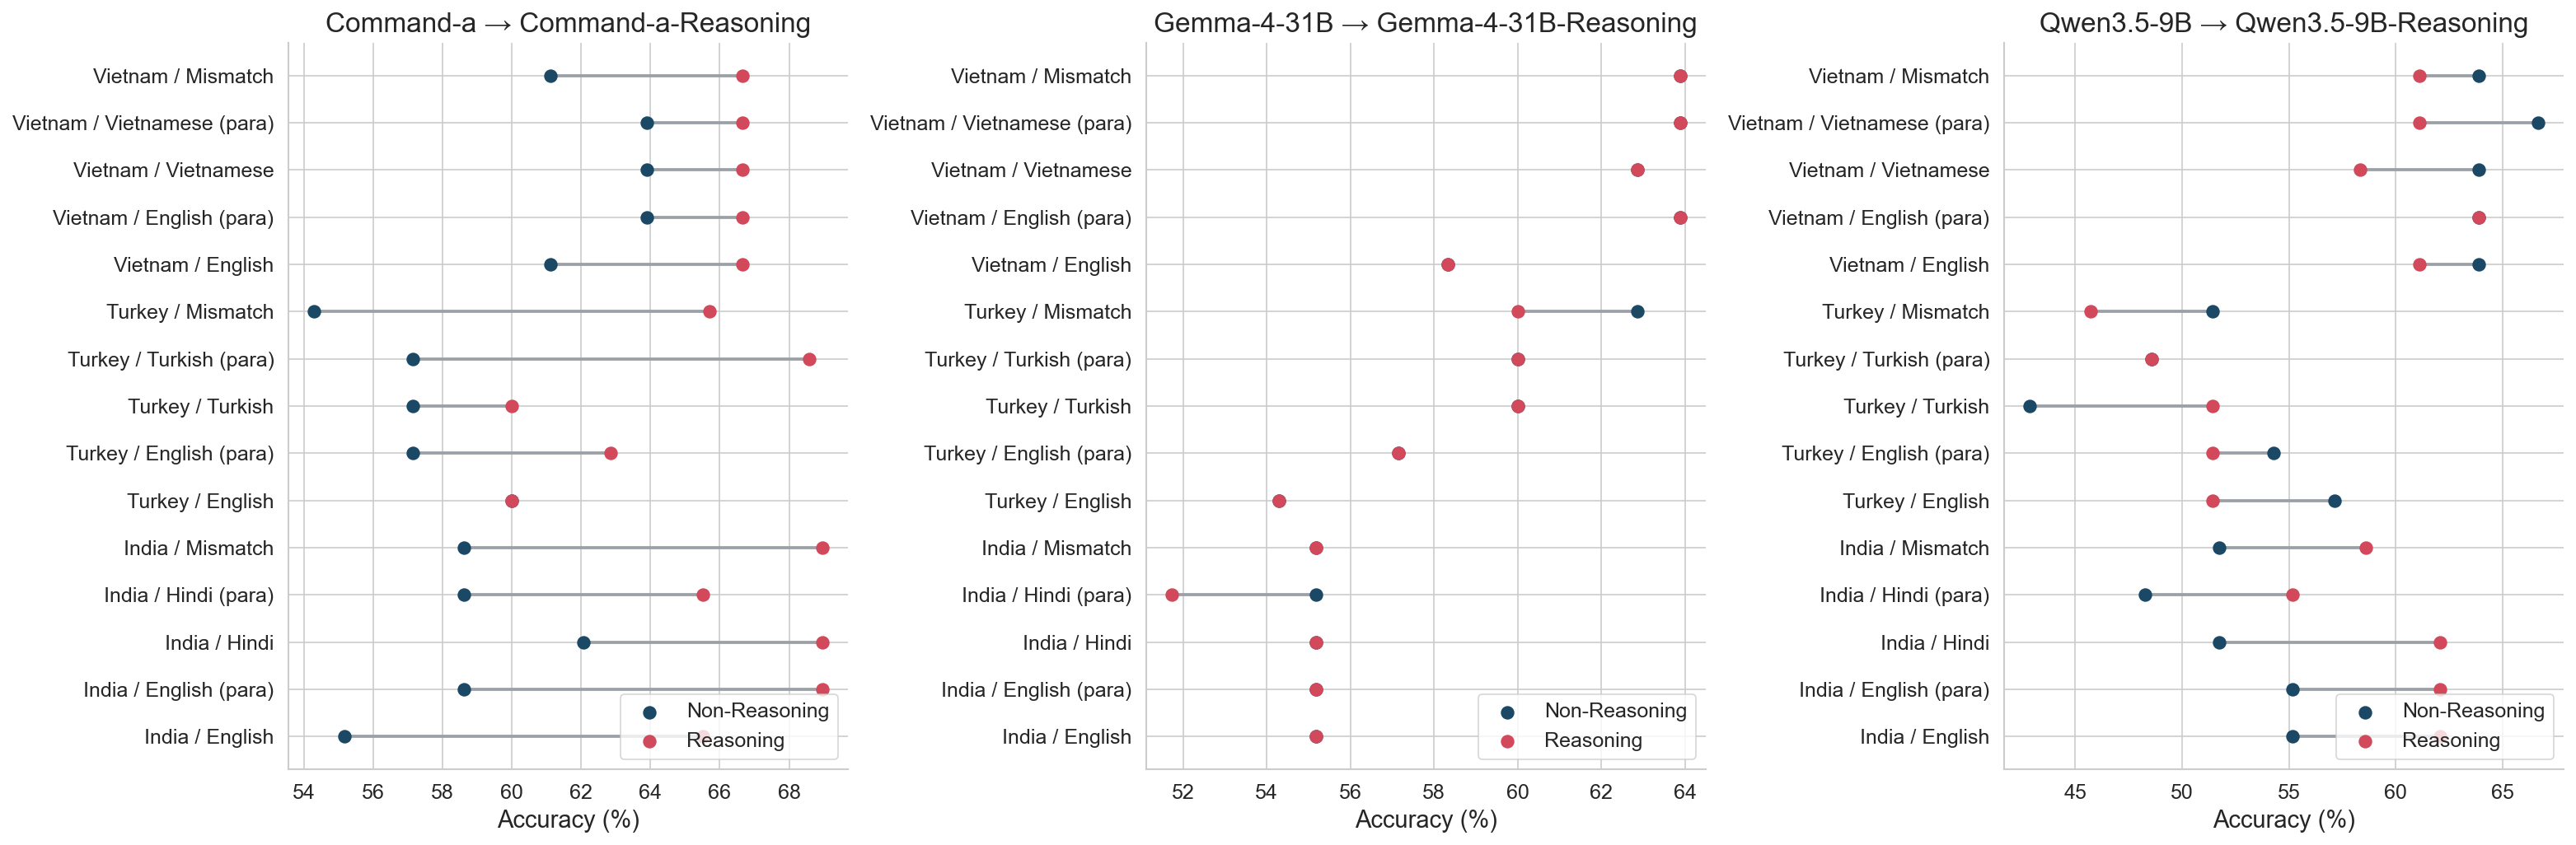

In [12]:
fig, axes = plt.subplots(1, len(reason_pairs), figsize=(7*len(reason_pairs), 7), squeeze=False)
for idx, (label, pdf) in enumerate(reason_pairs.items()):
    clean = pdf.query("pair_available and context_type=='COUNTRY' and conflict_type=='NONE'")
    if clean.empty: continue
    slope = (clean.groupby(["country","lang_condition"]).agg(nr_acc=("left_accuracy","mean"),r_acc=("right_accuracy","mean"),n=("scenario_id","size"))
        .reset_index().sort_values(["country","lang_condition"]))
    ax = axes[0, idx]; yp = np.arange(len(slope))
    for y, row in zip(yp, slope.itertuples()):
        actual = resolve_language(row.country, row.lang_condition)
        ax.plot([row.nr_acc*100, row.r_acc*100], [y,y], color="#9AA0A6", lw=1.8)
        ax.scatter(row.nr_acc*100, y, color=PAL[0], s=50, zorder=5, label="Non-Reasoning" if y==0 else "")
        ax.scatter(row.r_acc*100, y, color=PAL[3], s=50, zorder=5, label="Reasoning" if y==0 else "")
    ax.set_yticks(yp)
    ax.set_yticklabels([f"{r.country} / {resolve_language(r.country, r.lang_condition)}" for r in slope.itertuples()])
    ax.set_xlabel("Accuracy (%)"); ax.set_title(label); ax.legend(loc="lower right", fontsize=12)
plt.tight_layout(); plt.savefig(PLOTS/"reasoning_slope_all.png", bbox_inches="tight"); plt.show(); plt.close()


## 7. Context & Conflict Effects

In [13]:
cond_comps = [
    ("COUNTRY_NONE","NONE_NONE","Country → No context"),
    ("COUNTRY_NONE","VALUES_NONE","Country → Values"),
    ("COUNTRY_NONE","RULES_NONE","Country → Rules"),
    ("RULES_NONE","RULES_WRONG_RULES","Rules → Wrong rules"),
    ("RULES_NONE","RULES_WRONG_COUNTRY","Rules → Wrong country"),
    ("COUNTRY_NONE","COUNTRY_MADE_UP","Country → Made-up country"),
]
cond_pairs = {}
for l,r,desc in cond_comps:
    if {l,r}.issubset(results["condition_label"].unique()):
        cond_pairs[desc] = build_pairs(results, COND_PAIR_IDX, "condition_label", l, r, PAIR_VCOLS, {"lang_condition":"EN"})

cond_summary = pd.concat([
    summarize_pairs(p).assign(comparison=k) for k,p in cond_pairs.items()
], ignore_index=True).sort_values("acc_delta")
print("=== Context/Conflict Effects (sorted by accuracy delta) ===")
for _,r in cond_summary.iterrows():
    print(f"  {r.comparison:30s}  flip={r.flip_rate*100:.1f}%  Δ={r.acc_delta*100:+.1f}pp  C2W={r.c2w_rate*100:.1f}%  W2C={r.w2c_rate*100:.1f}%")

=== Context/Conflict Effects (sorted by accuracy delta) ===
  Rules → Wrong rules             flip=51.0%  Δ=-39.3pp  C2W=43.3%  W2C=4.0%
  Country → Made-up country       flip=48.5%  Δ=-10.2pp  C2W=26.8%  W2C=16.6%
  Country → No context            flip=19.3%  Δ=-4.2pp  C2W=8.9%  W2C=4.7%
  Rules → Wrong country           flip=1.6%  Δ=-0.2pp  C2W=0.8%  W2C=0.6%
  Country → Values                flip=13.9%  Δ=+5.6pp  C2W=1.2%  W2C=6.8%
  Country → Rules                 flip=34.0%  Δ=+26.9pp  C2W=0.7%  W2C=27.6%


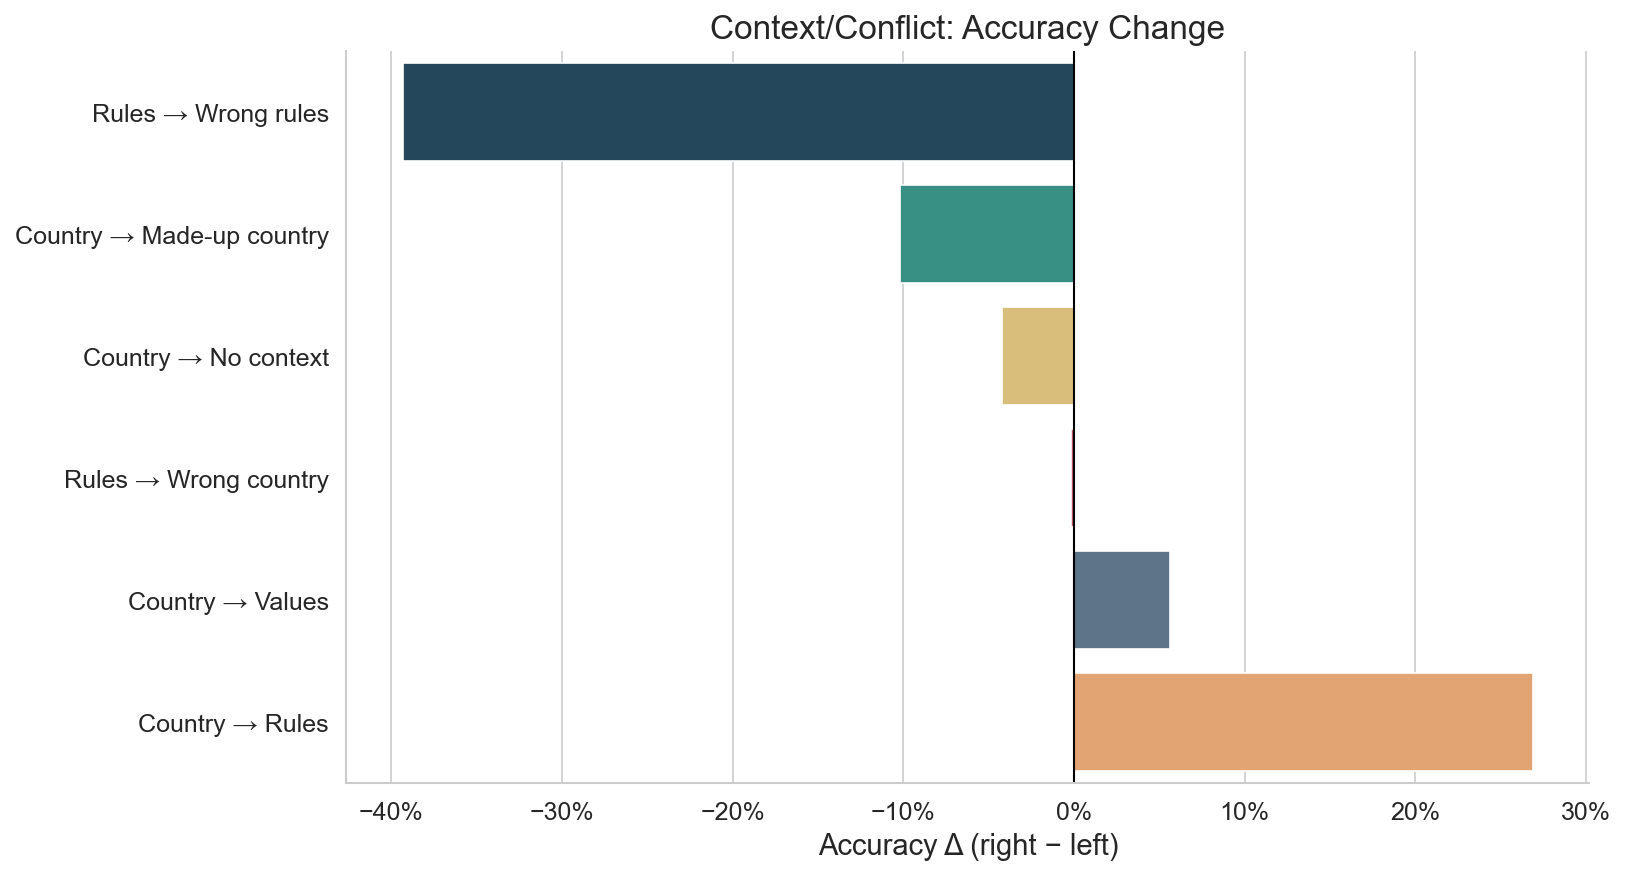

In [14]:
fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(data=cond_summary, y="comparison", x="acc_delta", hue="comparison", dodge=False, legend=False, ax=ax)
ax.axvline(0, color="black", lw=1); ax.set_xlabel("Accuracy Δ (right − left)")
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0)); ax.set_ylabel("")
ax.set_title("Context/Conflict: Accuracy Change"); plt.tight_layout()
plt.savefig(PLOTS/"context_conflict_delta.png", bbox_inches="tight"); plt.show(); plt.close()


## 8. Regional vs Global (Tiny-Aya)

In [15]:
regional_map = {"India":"Fire","Turkey":"Earth","Vietnam":"Water"}
print("=== Regional vs Global (Tiny-Aya) by Language Condition ===")
for country, regional in regional_map.items():
    c_df = results[results["country"]==country]
    g_acc = c_df[c_df["model"]=="Global"].groupby("lang_condition")["accuracy"].mean()
    r_acc = c_df[c_df["model"]==regional].groupby("lang_condition")["accuracy"].mean()
    print(f"\n  {country} (Global vs {regional}, local={COUNTRY_LOCAL_LANG[country]}):")
    for cond in LANG_CONDITION_ORDER:
        actual = resolve_language(country, cond)
        ga = g_acc.get(cond, np.nan)*100; ra = r_acc.get(cond, np.nan)*100
        d = ra - ga if not (np.isnan(ga) or np.isnan(ra)) else np.nan
        if pd.notna(d):
            print(f"    {cond:12s} ({actual:20s})  Global={ga:5.1f}%  {regional}={ra:5.1f}%  Δ={d:+.1f}pp")
        else:
            print(f"    {cond:12s} ({actual:20s})  Global={ga:5.1f}%  {regional}=N/A")

=== Regional vs Global (Tiny-Aya) by Language Condition ===

  India (Global vs Fire, local=Hindi):
    EN           (English             )  Global= 49.3%  Fire= 43.3%  Δ=-5.9pp
    EN_PARA      (English (para)      )  Global= 34.5%  Fire= 34.5%  Δ=+0.0pp
    LOCAL        (Hindi               )  Global= 41.4%  Fire= 44.8%  Δ=+3.4pp
    LOCAL_PARA   (Hindi (para)        )  Global= 37.9%  Fire= 34.5%  Δ=-3.4pp
    MISMATCH     (Mismatch            )  Global= 48.3%  Fire= 44.8%  Δ=-3.4pp

  Turkey (Global vs Earth, local=Turkish):
    EN           (English             )  Global= 55.1%  Earth= 50.6%  Δ=-4.5pp
    EN_PARA      (English (para)      )  Global= 42.9%  Earth= 40.0%  Δ=-2.9pp
    LOCAL        (Turkish             )  Global= 45.7%  Earth= 48.6%  Δ=+2.9pp
    LOCAL_PARA   (Turkish (para)      )  Global= 42.9%  Earth= 54.3%  Δ=+11.4pp
    MISMATCH     (Mismatch            )  Global= 45.7%  Earth= 42.9%  Δ=-2.9pp

  Vietnam (Global vs Water, local=Vietnamese):
    EN           (Engl

### 8.2 Domain-level Accuracy (Tiny-Aya Variants)

We analyze performance across specific cultural domains for the Global and Regional (Fire, Earth, Water) models. Note that domains are mapped from the original NormAd labels.

In [16]:
# Load domain mapping from merged results
df_merged = pd.read_csv('../notebooks/merged_experiment_results.csv')
id_to_domain = df_merged.groupby('scenario_id (Unique ID from NormAd dataset)')['domain (etiquette, eating, visiting etc)'].first().to_dict()
results['domain'] = results['scenario_id'].astype(str).map({str(k):v for k,v in id_to_domain.items()})

# Tiny-Aya models
ta_models = ['Global', 'Fire', 'Earth', 'Water']
df_ta = results[results['model'].isin(ta_models)].copy()

# Domain renaming for paper (mapping NormAd labels to paper domains)
domain_map = {
    'basic_etiquette': 'etiquette',
    'visiting': 'visiting',
    'eating': 'eating',
    'gift_giving': 'social_interactions',
    'gifts': 'social_interactions',
    'manners_in_vietnam': 'public_behavior'
}
df_ta['domain_paper'] = df_ta['domain'].map(domain_map)

# Domains defined in the ICML draft
PAPER_DOMAINS = [
    'etiquette', 
    'visiting', 
    'eating', 
    'social_interactions', 
    'public_behavior', 
    'business_etiquette', 
    'weddings_funerals'
]

print("=== Domain-level Accuracy: Tiny-Aya Regional Variants ===")
domain_table = []
for d in PAPER_DOMAINS:
    row = {'Domain': d}
    # Global baseline (across all countries for this domain)
    row['Global'] = df_ta[(df_ta['domain_paper']==d) & (df_ta['model']=='Global')]['accuracy'].mean()
    # Turkey (Earth model accuracy in Turkey)
    row['Turkey'] = df_ta[(df_ta['domain_paper']==d) & (df_ta['model']=='Earth') & (df_ta['country']=='Turkey')]['accuracy'].mean()
    # Vietnam (Water model accuracy in Vietnam)
    row['Vietnam'] = df_ta[(df_ta['domain_paper']==d) & (df_ta['model']=='Water') & (df_ta['country']=='Vietnam')]['accuracy'].mean()
    # India (Fire model accuracy in India)
    row['India'] = df_ta[(df_ta['domain_paper']==d) & (df_ta['model']=='Fire') & (df_ta['country']=='India')]['accuracy'].mean()
    domain_table.append(row)

df_domain = pd.DataFrame(domain_table)
display(df_domain)

# Generate LaTeX for Section 3.2 Table
latex_tbl = "\\begin{tabular}{lcccc}\n\\toprule\nDomain & Global & Turkey & Vietnam & India \\\\\n\\midrule\n"
for _, r in df_domain.iterrows():
    vals = [f"{v*100:4.1f}" if pd.notna(v) else " -- " 
            for v in [r.Global, r.Turkey, r.Vietnam, r.India]]
    
    domain_name = r.Domain.replace('_', r'\_')
    latex_tbl += f"{domain_name:20s} & {' & '.join(vals)} \\\\\n"
latex_tbl += "\\bottomrule\n\\end{tabular}"
print("\n=== LaTeX Table Code for tab:tinyaya_domain ===\n")
print(latex_tbl)

=== Domain-level Accuracy: Tiny-Aya Regional Variants ===


,Domain,Global,Turkey,Vietnam,India
0,etiquette,0.501684,0.484848,0.434343,0.505051
1,visiting,0.587879,0.444444,NaN,0.590909
2,eating,0.488215,0.515152,0.555556,0.393939
3,social_interactions,0.491736,0.522727,0.686869,0.109091
4,public_behavior,0.535354,NaN,0.575758,NaN
5,business_etiquette,NaN,NaN,NaN,NaN
6,weddings_funerals,NaN,NaN,NaN,NaN



=== LaTeX Table Code for tab:tinyaya_domain ===

\begin{tabular}{lcccc}
\toprule
Domain & Global & Turkey & Vietnam & India \\
\midrule
etiquette            & 50.2 & 48.5 & 43.4 & 50.5 \\
visiting             & 58.8 & 44.4 &  --  & 59.1 \\
eating               & 48.8 & 51.5 & 55.6 & 39.4 \\
social\_interactions & 49.2 & 52.3 & 68.7 & 10.9 \\
public\_behavior     & 53.5 &  --  & 57.6 &  --  \\
business\_etiquette  &  --  &  --  &  --  &  --  \\
weddings\_funerals   &  --  &  --  &  --  &  --  \\
\bottomrule
\end{tabular}


## 9. Generate Paper-Ready Outputs

In [17]:
with pd.ExcelWriter(OUT/"phase3_results_sheet.xlsx", engine="openpyxl") as w:
    acc_overall.reset_index().rename(columns={"index":"Model","accuracy":"Accuracy"}).to_excel(w, sheet_name="Overall Ranking", index=False)
    acc_mc = (results.groupby(["model","country"])["accuracy"].mean().unstack("country")
        .reindex(index=MODEL_ORDER).reindex(columns=COUNTRY_ORDER).dropna(how="all"))
    (acc_mc*100).round(1).to_excel(w, sheet_name="Accuracy by Country")
    (acc_by_cond*100).round(1).to_excel(w, sheet_name="Acc by Lang Condition")
    lang_summary.to_excel(w, sheet_name="Lang Cond Robustness", index=False)
    reason_summary.to_excel(w, sheet_name="Reasoning Toggle", index=False)
    cond_summary.to_excel(w, sheet_name="Context Conflict", index=False)
    reason_by_c = pd.concat([summarize_pairs(p,["country"]).assign(comparison=k) for k,p in reason_pairs.items()], ignore_index=True)
    reason_by_c.to_excel(w, sheet_name="Reasoning by Country", index=False)
    best_cl = (results.groupby(["country","lang_condition","model"])["accuracy"].mean().reset_index()
        .sort_values(["country","lang_condition","accuracy"], ascending=[True,True,False])
        .groupby(["country","lang_condition"]).head(3))
    best_cl["actual_language"] = best_cl.apply(lambda r: resolve_language(r["country"], r["lang_condition"]), axis=1)
    best_cl["accuracy"] = (best_cl["accuracy"]*100).round(1)
    best_cl.to_excel(w, sheet_name="Top3 per Cond-Country", index=False)
print(f"Excel sheet saved to {OUT/'phase3_results_sheet.xlsx'}")

Excel sheet saved to ./final_analysis/final_analysis_outputs/phase3_results_sheet.xlsx


In [18]:
def pct(v): return f"{v*100:.1f}\\%"
macro = ["% Auto-generated — do not edit by hand.",
    f"\\newcommand{{\\TotalRawRuns}}{{{len(raw_runs):,}}}",
    f"\\newcommand{{\\TotalConditions}}{{{len(results):,}}}",
    f"\\newcommand{{\\NumModels}}{{{results['model'].nunique()}}}",
]
for m,a in acc_overall.items():
    safe = str(m).replace("-","").replace(".","").replace(" ","")
    macro.append(f"\\newcommand{{\\Acc{safe}}}{{{a*100:.1f}\\%}}")
for country in COUNTRY_ORDER:
    ca = results[results["country"]==country].groupby("model")["accuracy"].mean()
    best_m, best_a = ca.idxmax(), ca.max()
    sc = country.replace(" ","")
    macro.append(f"\\newcommand{{\\BestModel{sc}}}{{{best_m}}}")
    macro.append(f"\\newcommand{{\\BestAcc{sc}}}{{{best_a*100:.1f}\\%}}")
for _,r in cond_summary.iterrows():
    tag = r.comparison.replace(" ","").replace("→","To").replace("_","")
    macro.append(f"\\newcommand{{\\Cond{tag}Flip}}{{{r.flip_rate*100:.1f}\\%}}")
    macro.append(f"\\newcommand{{\\Cond{tag}Delta}}{{{r.acc_delta*100:+.1f}}}")
    macro.append(f"\\newcommand{{\\Cond{tag}CTW}}{{{r.c2w_rate*100:.1f}\\%}}")
    macro.append(f"\\newcommand{{\\Cond{tag}WTC}}{{{r.w2c_rate*100:.1f}\\%}}")
for _,r in reason_summary.iterrows():
    tag = r.comparison.replace(" ","").replace("→","To").replace("-","").replace(".","")
    macro.append(f"\\newcommand{{\\Reason{tag}Flip}}{{{r.flip_rate*100:.1f}\\%}}")
    macro.append(f"\\newcommand{{\\Reason{tag}Delta}}{{{r.acc_delta*100:+.1f}}}")
    macro.append(f"\\newcommand{{\\Reason{tag}NRAcc}}{{{r.left_acc*100:.1f}\\%}}")
    macro.append(f"\\newcommand{{\\Reason{tag}RAcc}}{{{r.right_acc*100:.1f}\\%}}")
(PAPER/"paper_macros.tex").write_text("\n".join(macro)+"\n")
print(f"Wrote {len(macro)} macros")

Wrote 58 macros


In [19]:
# Table: Accuracy by model
tbl = ["\\begin{table*}[t]","\\centering\\footnotesize","\\setlength{\\tabcolsep}{5pt}",
    "\\begin{tabular}{l"+"r"*(1+len(COUNTRY_ORDER))+"}","\\toprule",
    "Model & Overall & "+" & ".join(COUNTRY_ORDER)+" \\\\","\\midrule"]
for m in MODEL_ORDER:
    if m not in acc_overall.index: continue
    cells = [m, f"{acc_overall[m]*100:.1f}"]
    for c in COUNTRY_ORDER:
        v = acc_mc.loc[m,c] if m in acc_mc.index and pd.notna(acc_mc.loc[m,c]) else np.nan
        cells.append(f"{v*100:.1f}" if pd.notna(v) else "---")
    tbl.append(" & ".join(cells)+" \\\\")
tbl += ["\\bottomrule","\\end{tabular}",
    f"\\caption{{Accuracy (\\%) by model and country ({len(results):,} conditions from {len(raw_runs):,} raw runs).}}",
    "\\label{tab:accuracy-by-model}","\\end{table*}"]
(PAPER/"tab_accuracy_by_model.tex").write_text("\n".join(tbl)+"\n")

# Table: Context/conflict
tbl = ["\\begin{table*}[t]","\\centering\\footnotesize","\\setlength{\\tabcolsep}{4.5pt}",
    "\\begin{tabularx}{\\textwidth}{Xrrrrr}","\\toprule",
    "Comparison & Pairs & Flip & Acc. $\\Delta$ & C2W & W2C \\\\","\\midrule"]
for _,r in cond_summary.iterrows():
    tbl.append(f"{r.comparison} & {int(r.n_pairs)} & {r.flip_rate*100:.1f}\\% & ${r.acc_delta*100:+.1f}$ pp & {r.c2w_rate*100:.1f}\\% & {r.w2c_rate*100:.1f}\\% \\\\")
tbl += ["\\bottomrule","\\end{tabularx}","\\caption{Context and conflict effects.}","\\label{tab:context-conflict}","\\end{table*}"]
(PAPER/"tab_context_conflict.tex").write_text("\n".join(tbl)+"\n")

# Table: Language conditions
tbl = ["\\begin{table*}[t]","\\centering\\footnotesize","\\setlength{\\tabcolsep}{5pt}",
    "\\begin{tabularx}{\\textwidth}{Xrrrrr}","\\toprule",
    "Comparison & Pairs & Flip & Acc. $\\Delta$ & C2W & W2C \\\\","\\midrule"]
for _,r in lang_summary.iterrows():
    tbl.append(f"{r.comparison} & {int(r.n_pairs)} & {r.flip_rate*100:.1f}\\% & ${r.acc_delta*100:+.1f}$ pp & {r.c2w_rate*100:.1f}\\% & {r.w2c_rate*100:.1f}\\% \\\\")
tbl += ["\\bottomrule","\\end{tabularx}","\\caption{Language perturbation effects. EN=English, LOCAL=Hindi/Turkish/Vietnamese per country, MISMATCH=unrelated language.}","\\label{tab:language}","\\end{table*}"]
(PAPER/"tab_language.tex").write_text("\n".join(tbl)+"\n")

# Table: Reasoning (all 3 families)
tbl = ["\\begin{table*}[t]","\\centering\\footnotesize","\\setlength{\\tabcolsep}{4pt}",
    "\\begin{tabularx}{\\textwidth}{Xrrrrrrr}","\\toprule",
    "Comparison & Pairs & Flip & Acc. $\\Delta$ & C2W & W2C & NR Acc & R Acc \\\\","\\midrule"]
for _,r in reason_summary.iterrows():
    c = r.comparison.replace("_","\\_")
    tbl.append(f"{c} & {int(r.n_pairs)} & {r.flip_rate*100:.1f}\\% & ${r.acc_delta*100:+.1f}$ pp & {r.c2w_rate*100:.1f}\\% & {r.w2c_rate*100:.1f}\\% & {r.left_acc*100:.1f}\\% & {r.right_acc*100:.1f}\\% \\\\")
tbl += ["\\bottomrule","\\end{tabularx}","\\caption{Reasoning toggle: within-family comparisons for all three model families.}","\\label{tab:reasoning}","\\end{table*}"]
(PAPER/"tab_reasoning.tex").write_text("\n".join(tbl)+"\n")

print(f"\nAll paper outputs written to {PAPER}/")


All paper outputs written to ./final_analysis/final_analysis_outputs/paper/


## 10. Summary: Numbers to Update in paper.tex

In [20]:
print("="*70)
print("NUMBERS TO UPDATE IN paper.tex")
print("="*70)
print(f"\n1. ABSTRACT & INTRO:")
print(f"   - Total raw runs: {len(raw_runs):,} (was 21,992)")
print(f"   - Total conditions: {len(results):,} (was 4,399)")
print(f"   - Models: {results['model'].nunique()} (was 6: now includes Qwen3.5 + Gemma-4)")
cs = cond_summary.set_index("comparison")
if "Country → Rules" in cs.index:
    r = cs.loc["Country → Rules"]
    print(f"   - Rules improve accuracy by {r.acc_delta*100:+.1f}pp (was +25.2)")
if "Rules → Wrong rules" in cs.index:
    r = cs.loc["Rules → Wrong rules"]
    print(f"   - Wrong rules reduce accuracy by {r.acc_delta*100:+.1f}pp (was -29.2)")
    print(f"   - Wrong rules C2W rate: {r.c2w_rate*100:.1f}% (was 34.5%)")

print(f"\n2. SECTION 3 (Experimental Setup):")
print(f"   - Add Qwen3.5-0.8B, Qwen3.5-2B, Qwen3.5-9B (NR/R), Gemma-4-31B (NR/R)")
print(f"   - Update model count to {results['model'].nunique()}")

print(f"\n3. TABLES: All regenerated in final_analysis_outputs/paper/")
print(f"   - Reasoning table: 3 within-family rows (no cross-model)")

print(f"\n4. SECTION 4.3 (Reasoning) — rewrite for all 3 families:")
for _,r in reason_summary.iterrows():
    print(f"   - {r.comparison}: flip={r.flip_rate*100:.1f}%, Δ={r.acc_delta*100:+.1f}pp")
print("="*70)

NUMBERS TO UPDATE IN paper.tex

1. ABSTRACT & INTRO:
   - Total raw runs: 53,927 (was 21,992)
   - Total conditions: 10,966 (was 4,399)
   - Models: 12 (was 6: now includes Qwen3.5 + Gemma-4)
   - Rules improve accuracy by +26.9pp (was +25.2)
   - Wrong rules reduce accuracy by -39.3pp (was -29.2)
   - Wrong rules C2W rate: 43.3% (was 34.5%)

2. SECTION 3 (Experimental Setup):
   - Add Qwen3.5-0.8B, Qwen3.5-2B, Qwen3.5-9B (NR/R), Gemma-4-31B (NR/R)
   - Update model count to 12

3. TABLES: All regenerated in final_analysis_outputs/paper/
   - Reasoning table: 3 within-family rows (no cross-model)

4. SECTION 4.3 (Reasoning) — rewrite for all 3 families:
   - Command-a → Command-a-Reasoning: flip=19.0%, Δ=+4.4pp
   - Gemma-4-31B → Gemma-4-31B-Reasoning: flip=0.5%, Δ=-0.2pp
   - Qwen3.5-9B → Qwen3.5-9B-Reasoning: flip=18.3%, Δ=-0.1pp


## 11. Provider Comparison (Cohere · Qwen · Gemma)

Aggregate performance by **model provider** to surface family-level patterns
that go beyond individual checkpoints. Uses metadata attached during
aggregation (`provider`, `model_family`, `model_size_b`, `is_reasoning`).

In [21]:
# 11.1 Provider × country accuracy
prov_country = (results.groupby(["provider","country"])["accuracy"].mean()
    .unstack("country").reindex(columns=COUNTRY_ORDER))
prov_overall = results.groupby("provider")["accuracy"].mean().rename("Overall")
prov_table = pd.concat([prov_overall, prov_country], axis=1).sort_values("Overall", ascending=False)
print("=== Mean accuracy (%) by provider ===")
print((prov_table*100).round(1).to_string())

=== Mean accuracy (%) by provider ===
          Overall  India  Turkey  Vietnam
provider                                 
Gemma        59.8   55.5    60.9     62.0
Cohere       56.1   51.9    55.9     59.7
Qwen         54.2   51.6    54.8     55.5


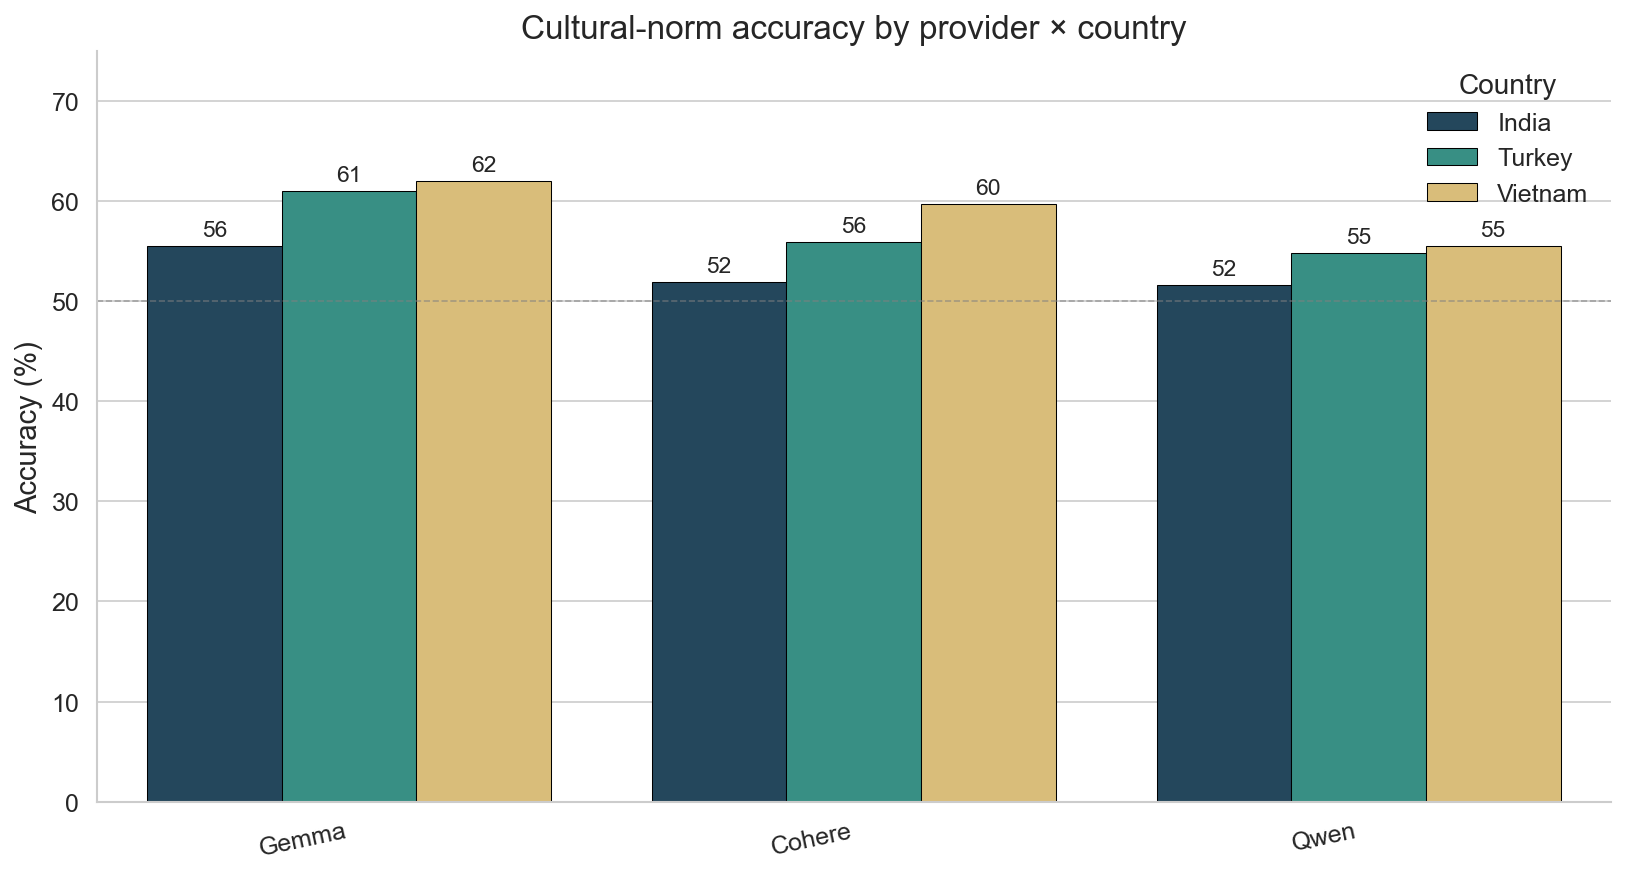

In [22]:
# 11.2 Paper-grade grouped bar: provider × country
prov_long = (results.groupby(["provider","country"])["accuracy"].mean()
    .reset_index().rename(columns={"accuracy":"acc"}))
prov_long["acc"] *= 100
prov_long["provider"] = pd.Categorical(prov_long["provider"], categories=prov_table.index, ordered=True)

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(data=prov_long, x="provider", y="acc", hue="country",
            hue_order=COUNTRY_ORDER, palette=PAL[:3], ax=ax, edgecolor="black", linewidth=0.5)
for p in ax.patches:
    h = p.get_height()
    if pd.notna(h) and h > 0:
        ax.annotate(f"{h:.0f}", (p.get_x()+p.get_width()/2, h+0.6),
                    ha="center", va="bottom", fontsize=11)
ax.axhline(50, color="grey", lw=0.8, ls="--", alpha=0.6)
ax.set_xlabel(""); ax.set_ylabel("Accuracy (%)"); ax.set_ylim(0, 75)
ax.set_title("Cultural-norm accuracy by provider × country")
ax.legend(title="Country", frameon=False, loc="upper right", fontsize=12)
plt.setp(ax.get_xticklabels(), rotation=12, ha="right")
plt.tight_layout(); plt.savefig(PLOTS/"provider_country.pdf", bbox_inches="tight")
plt.savefig(PLOTS/"provider_country.png", bbox_inches="tight"); plt.show(); plt.close()


In [23]:
# 11.3 Best per-condition winner (provider) — quick read of who wins where
prov_cond = (results.groupby(["provider","lang_condition"])["accuracy"].mean()
    .unstack("lang_condition").reindex(columns=LANG_CONDITION_ORDER))
print("=== Best provider per language condition ===")
for c in LANG_CONDITION_ORDER:
    if c in prov_cond.columns:
        best = prov_cond[c].idxmax()
        print(f"  {c:11s}  {best:25s}  {prov_cond.loc[best,c]*100:.1f}%")

=== Best provider per language condition ===
  EN           Gemma                      59.8%
  EN_PARA      Gemma                      59.0%
  LOCAL        Gemma                      59.8%
  LOCAL_PARA   Gemma                      59.5%
  MISMATCH     Gemma                      60.5%


## 12. Model Size Scaling (Qwen3.5 0.8B → 2B → 9B)

Qwen is the only family with three non-reasoning checkpoints across the
parameter axis, so it lets us test whether **scale alone** improves
cultural-norm robustness — separately from the reasoning toggle.

In [24]:
# 12.1 Accuracy vs parameter count
qwen_nr = ["Qwen3.5-0.8B","Qwen3.5-2B","Qwen3.5-9B"]
qsub = results[results["model"].isin(qwen_nr)].copy()
qsub["params_B"] = qsub["model"].map(MODEL_SIZE_B)

scale_overall = (qsub.groupby(["model","params_B"])["accuracy"].mean()
    .reset_index().sort_values("params_B"))
scale_country = (qsub.groupby(["country","model","params_B"])["accuracy"].mean()
    .reset_index().sort_values(["country","params_B"]))

print("=== Qwen3.5 size scaling (overall) ===")
for _,r in scale_overall.iterrows():
    print(f"  {r.model:14s} ({r.params_B:>4.1f}B)  {r.accuracy*100:5.1f}%")

# Pearson correlation of log-params vs accuracy (per scenario, across the 3 sizes)
import numpy as _np
corr_rows = []
for country in COUNTRY_ORDER:
    s = scale_country[scale_country["country"]==country]
    if len(s) >= 2:
        r = _np.corrcoef(_np.log10(s["params_B"]), s["accuracy"])[0,1]
        corr_rows.append({"country": country, "pearson_log_r": round(r,3),
                          "delta_0p8_to_9B_pp": round((s.iloc[-1].accuracy - s.iloc[0].accuracy)*100, 1)})
corr_df = pd.DataFrame(corr_rows)
print("\n=== Qwen log-size vs accuracy correlation by country ===")
print(corr_df.to_string(index=False))

=== Qwen3.5 size scaling (overall) ===
  Qwen3.5-0.8B   ( 0.8B)   45.3%
  Qwen3.5-2B     ( 2.0B)   52.4%
  Qwen3.5-9B     ( 9.0B)   59.5%

=== Qwen log-size vs accuracy correlation by country ===
country  pearson_log_r  delta_0p8_to_9B_pp
  India          0.702                 6.6
 Turkey          0.906                 7.8
Vietnam          0.950                26.5


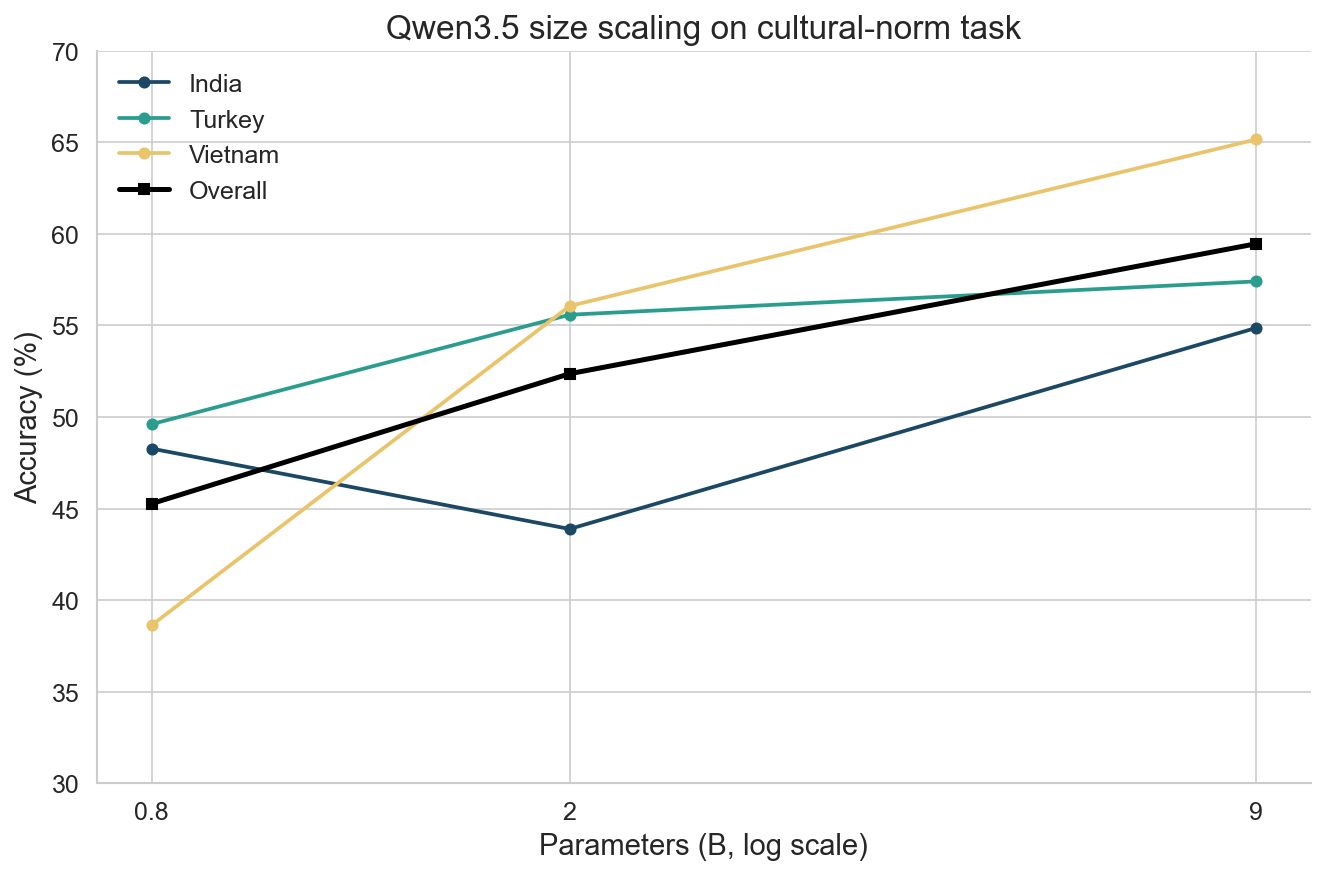

In [25]:
# 12.2 Scaling figure (log-x): one line per country + overall
fig, ax = plt.subplots(figsize=(9, 6))
for i, country in enumerate(COUNTRY_ORDER):
    s = scale_country[scale_country["country"]==country].sort_values("params_B")
    ax.plot(s["params_B"], s["accuracy"]*100, marker="o", lw=1.8,
            color=PAL[i], label=country)
ov = scale_overall.sort_values("params_B")
ax.plot(ov["params_B"], ov["accuracy"]*100, marker="s", lw=2.4,
        color="black", label="Overall")
ax.set_xscale("log"); ax.set_xticks([0.8, 2, 9])
ax.get_xaxis().set_major_formatter(mtick.FormatStrFormatter("%g"))
ax.set_xlabel("Parameters (B, log scale)"); ax.set_ylabel("Accuracy (%)")
ax.set_title("Qwen3.5 size scaling on cultural-norm task")
ax.legend(frameon=False, fontsize=12); ax.set_ylim(30, 70)
plt.tight_layout(); plt.savefig(PLOTS/"qwen_scaling.pdf", bbox_inches="tight")
plt.savefig(PLOTS/"qwen_scaling.png", bbox_inches="tight"); plt.show(); plt.close()


In [26]:
# 12.3 Does scale buy *robustness* (flip rate) in addition to accuracy?
# Build EN -> LOCAL pair flip rate per Qwen size, per country.
flip_rows = []
for m in qwen_nr:
    p = build_pairs(results[results["model"]==m], LANGCOND_PAIR_IDX,
                    "lang_condition", "EN", "LOCAL", PAIR_VCOLS,
                    {"context_type":"COUNTRY","conflict_type":"NONE"})
    s = summarize_pairs(p, ["country"])
    s["model"] = m; s["params_B"] = MODEL_SIZE_B[m]
    flip_rows.append(s)
qwen_flip = pd.concat(flip_rows, ignore_index=True)
print("=== Qwen size: EN→LOCAL flip rate (lower = more robust) ===")
piv = qwen_flip.pivot_table(index="country", columns="model",
                            values="flip_rate")[qwen_nr]*100
print(piv.round(1).to_string())

=== Qwen size: EN→LOCAL flip rate (lower = more robust) ===
model    Qwen3.5-0.8B  Qwen3.5-2B  Qwen3.5-9B
country                                      
India            20.7        31.0         6.9
Turkey           28.6        25.7        28.6
Vietnam          13.9        22.2         8.3


## 13. Statistical Significance (McNemar + Holm correction)

The pair tables above include McNemar p-values; here we apply
**Holm–Bonferroni** correction across the full set of pre-registered
comparisons (language × context × reasoning) and surface only effects that
survive at α = 0.05.

In [27]:
# 13.1 Build a single combined significance table.
# Each pair already exposes mcnemar_p; we just need to label and concat.
def _sig_block(pairs_dict, family_label):
    rows = []
    for label, pdf in pairs_dict.items():
        s = summarize_pairs(pdf)
        if s.empty: continue
        rec = s.iloc[0].to_dict()
        rec["family"] = family_label; rec["comparison"] = label
        rows.append(rec)
    return pd.DataFrame(rows)

sig_lang = _sig_block(lang_pairs, "Language")
sig_reason = _sig_block(reason_pairs, "Reasoning")
sig_cond = _sig_block(cond_pairs, "Context/Conflict")
sig_all = pd.concat([sig_lang, sig_reason, sig_cond], ignore_index=True)
sig_all["p_holm"] = holm(sig_all["mcnemar_p"].values)
sig_all["sig"]    = sig_all["p_holm"] < 0.05

cols = ["family","comparison","n_pairs","flip_rate","acc_delta",
        "c2w_rate","w2c_rate","mcnemar_p","p_holm","sig"]
sig_print = sig_all[cols].sort_values(["family","p_holm"]).reset_index(drop=True)
print("=== Holm-corrected significance across pre-registered comparisons ===")
with pd.option_context("display.float_format", lambda x: f"{x:.4f}",
                       "display.max_colwidth", 38, "display.width", 140):
    print(sig_print.to_string(index=False))
print(f"\n{sig_all['sig'].sum()}/{len(sig_all)} comparisons significant at α=0.05 (Holm).")

=== Holm-corrected significance across pre-registered comparisons ===
          family                          comparison   n_pairs  flip_rate  acc_delta  c2w_rate  w2c_rate  mcnemar_p  p_holm   sig
Context/Conflict                 Rules → Wrong rules  979.0000     0.5097    -0.3933    0.4331    0.0398     0.0000  0.0000  True
Context/Conflict                     Country → Rules  997.0000     0.3400     0.2688    0.0070    0.2758     0.0000  0.0000  True
Context/Conflict                    Country → Values  997.0000     0.1394     0.0562    0.0120    0.0682     0.0000  0.0000  True
Context/Conflict           Country → Made-up country  993.0000     0.4854    -0.1017    0.2679    0.1662     0.0000  0.0000  True
Context/Conflict                Country → No context  999.0000     0.1932    -0.0420    0.0891    0.0470     0.0004  0.0044  True
Context/Conflict               Rules → Wrong country  997.0000     0.0160    -0.0020    0.0080    0.0060     0.7905  1.0000 False
        Language    

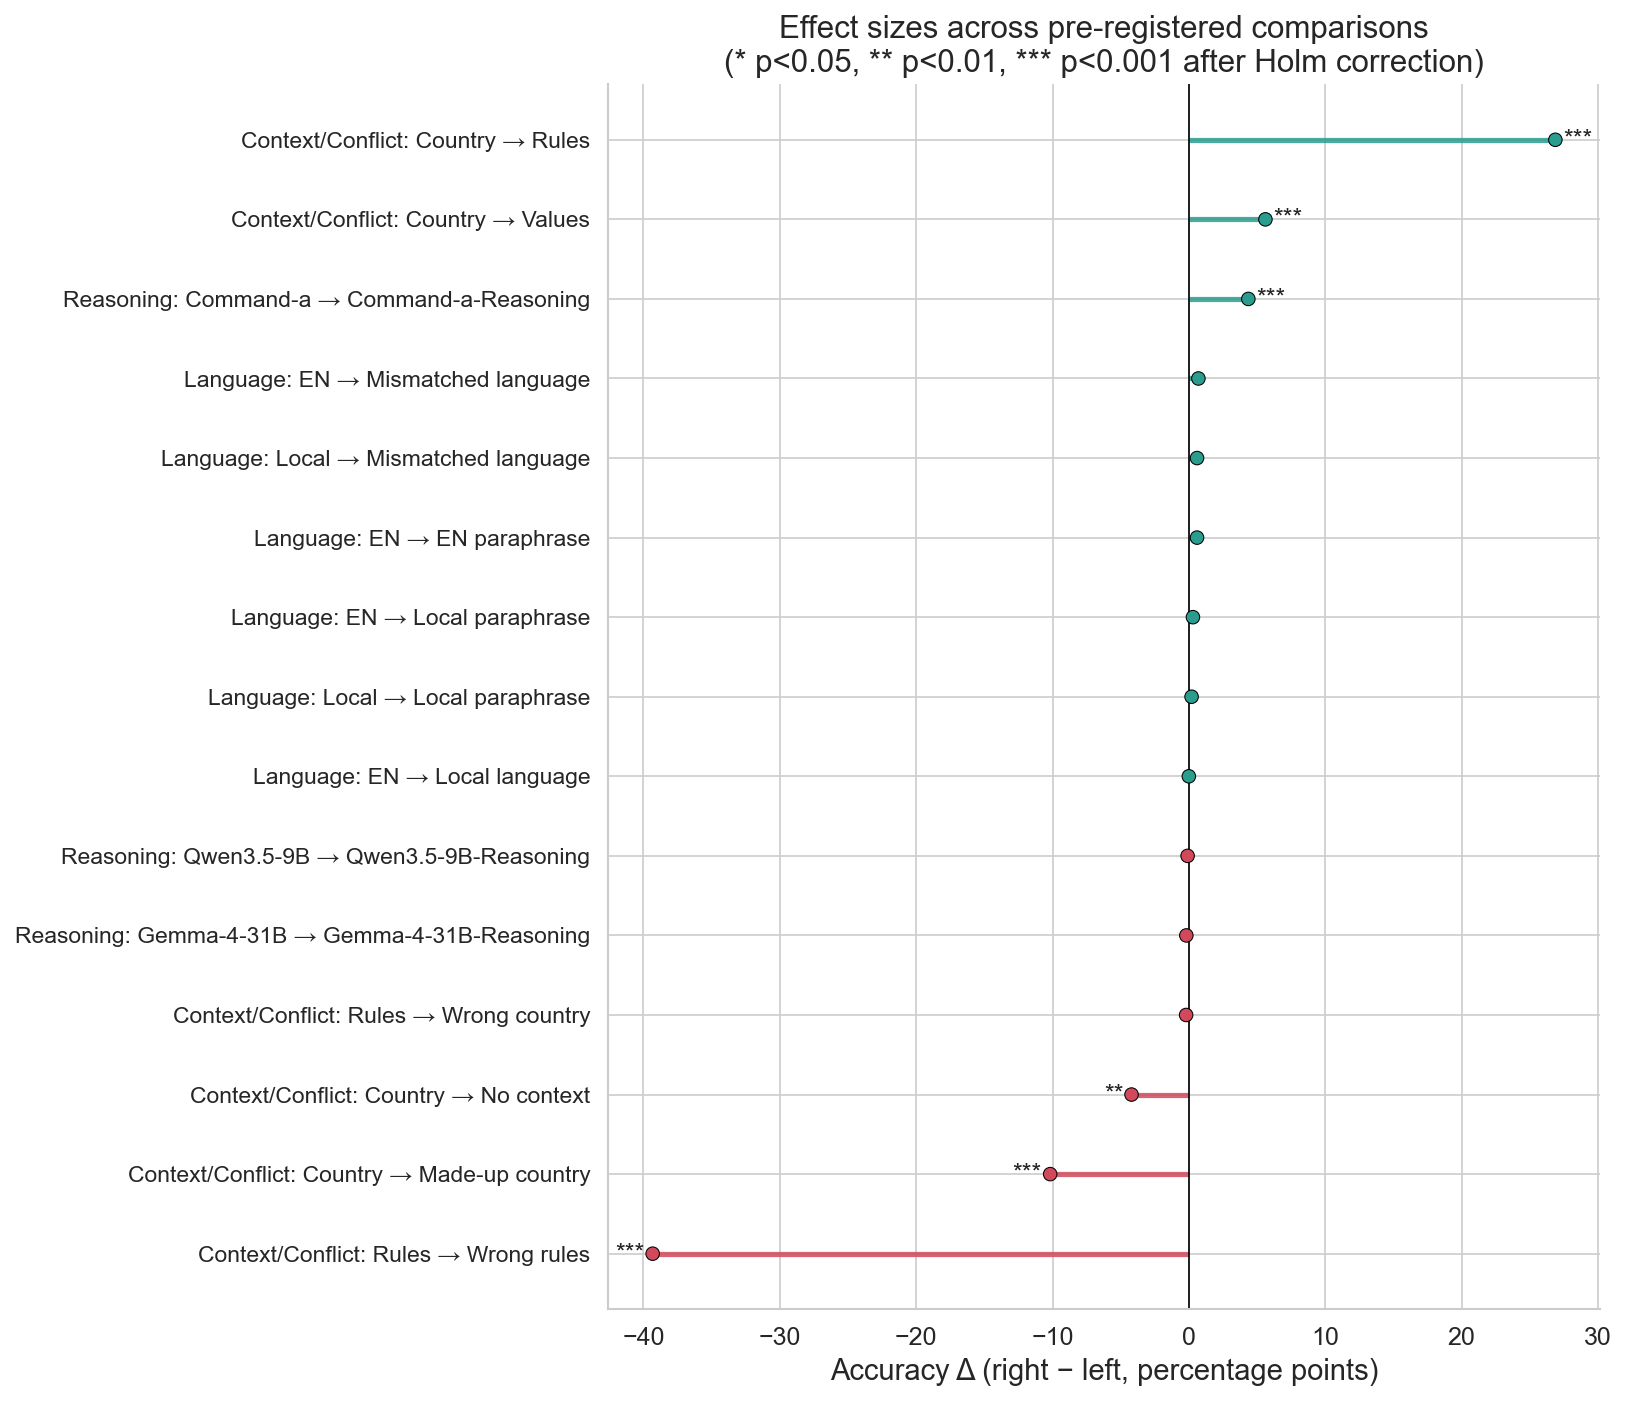

In [28]:
# 13.2 Forest plot of accuracy effects with 95% Wilson CIs on flip rate
fp = sig_all.sort_values("acc_delta").reset_index(drop=True).copy()
fp["label"] = fp["family"] + ": " + fp["comparison"]

fig, ax = plt.subplots(figsize=(11, 0.5*len(fp)+2))
y = np.arange(len(fp))
colors = ["#2A9D8F" if v >= 0 else "#D1495B" for v in fp["acc_delta"]]
ax.hlines(y, 0, fp["acc_delta"]*100, color=colors, lw=2.5, alpha=0.85)
ax.scatter(fp["acc_delta"]*100, y, color=colors, s=42, zorder=3,
           edgecolor="black", linewidth=0.5)
for i,(_,row) in enumerate(fp.iterrows()):
    star = "***" if row["p_holm"]<0.001 else ("**" if row["p_holm"]<0.01 else ("*" if row["p_holm"]<0.05 else ""))
    if star:
        ax.text(row["acc_delta"]*100 + (0.6 if row["acc_delta"]>=0 else -0.6),
                i, star, va="center",
                ha="left" if row["acc_delta"]>=0 else "right", fontsize=12)
ax.set_yticks(y); ax.set_yticklabels(fp["label"], fontsize=11)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Accuracy Δ (right − left, percentage points)")
ax.set_title("Effect sizes across pre-registered comparisons\n(* p<0.05, ** p<0.01, *** p<0.001 after Holm correction)",
             fontsize=15)
plt.tight_layout(); plt.savefig(PLOTS/"forest_significance.pdf", bbox_inches="tight")
plt.savefig(PLOTS/"forest_significance.png", bbox_inches="tight"); plt.show(); plt.close()


## 14. Conflict-Type Vulnerability by Provider

How does each provider react when given **wrong cultural context**?
We compute per-provider accuracy under each `conflict_type`
(in the `COUNTRY` / `RULES` context, EN language) and the drop relative to
the matched no-conflict baseline.

In [29]:
# 14.1 Provider × conflict accuracy with Δ vs NONE (matched context)
# Baseline NONE conflict uses CONTEXT=COUNTRY for MADE_UP / WRONG_COUNTRY's *implicit* baseline,
# but for WRONG_RULES the natural baseline is RULES_NONE. We report both views.
conflict_focus = results[results["lang_condition"]=="EN"].copy()

# View A: COUNTRY context family — compares NONE vs MADE_UP, WRONG_COUNTRY
viewA = conflict_focus[conflict_focus["context_type"]=="COUNTRY"]
A = (viewA.groupby(["provider","conflict_type"])["accuracy"].mean()
       .unstack("conflict_type")
       .reindex(columns=[c for c in CONFLICT_ORDER if c in {"NONE","MADE_UP","WRONG_COUNTRY"}]))
A["Δ MADE_UP"]       = (A.get("MADE_UP", np.nan) - A["NONE"])*100
A["Δ WRONG_COUNTRY"] = (A.get("WRONG_COUNTRY", np.nan) - A["NONE"])*100
print("=== Country-context perturbations (provider × conflict type) ===")
print((A.iloc[:, :A.columns.get_loc("Δ MADE_UP")]*100).round(1).to_string())
print()
print(A.iloc[:, A.columns.get_loc("Δ MADE_UP"):].round(1).to_string())

# View B: RULES context — RULES_NONE vs RULES_WRONG_RULES vs RULES_WRONG_COUNTRY
viewB = conflict_focus[conflict_focus["context_type"]=="RULES"]
B = (viewB.groupby(["provider","conflict_type"])["accuracy"].mean()
       .unstack("conflict_type"))
if "NONE" in B.columns:
    for col in ["WRONG_RULES","WRONG_COUNTRY"]:
        if col in B.columns:
            B[f"Δ {col}"] = (B[col]-B["NONE"])*100
print("\n=== Rules-context perturbations (provider × conflict type) ===")
print((B.filter(items=["NONE","WRONG_RULES","WRONG_COUNTRY"])*100).round(1).to_string())
delta_cols = [c for c in B.columns if str(c).startswith("Δ")]
if delta_cols:
    print()
    print(B[delta_cols].round(1).to_string())

=== Country-context perturbations (provider × conflict type) ===
conflict_type  NONE  WRONG_COUNTRY  MADE_UP
provider                                   
Cohere         52.2            NaN     43.2
Gemma          56.0            NaN     36.8
Qwen           52.0            NaN     44.8

conflict_type  Δ MADE_UP  Δ WRONG_COUNTRY
provider                                 
Cohere              -9.0              NaN
Gemma              -19.2              NaN
Qwen                -7.3              NaN

=== Rules-context perturbations (provider × conflict type) ===
          NONE  WRONG_RULES  WRONG_COUNTRY
provider                                  
Cohere    79.5         43.8           79.2
Gemma     91.4         32.2           90.5
Qwen      74.8         41.4           74.5

conflict_type  Δ WRONG_RULES  Δ WRONG_COUNTRY
provider                                     
Cohere                 -35.8             -0.3
Gemma                  -59.1             -0.9
Qwen                   -33.4            

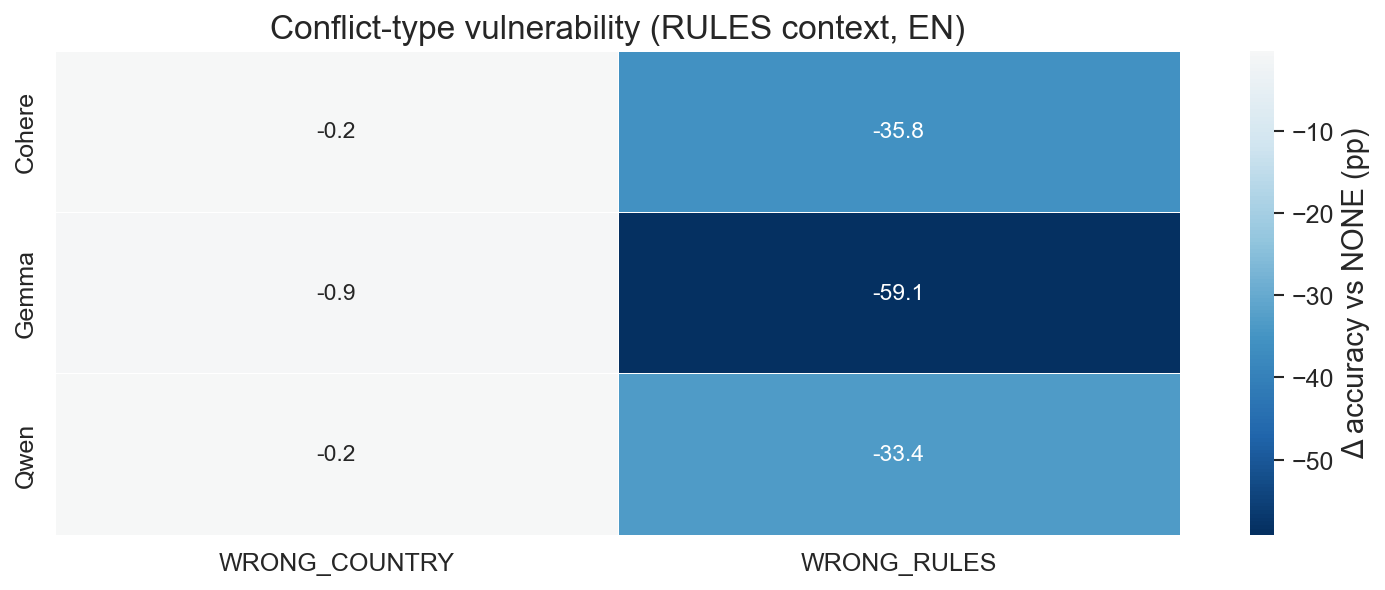

In [30]:
# 14.2 Heatmap: provider × conflict_type accuracy delta (RULES context, EN)
hm = (viewB.groupby(["provider","conflict_type"])["accuracy"].mean()
      .unstack("conflict_type")*100)
if "NONE" in hm.columns:
    hm_delta = hm.subtract(hm["NONE"], axis=0).drop(columns=["NONE"])
    fig, ax = plt.subplots(figsize=(10, 0.7*len(hm_delta)+2))
    sns.heatmap(hm_delta, annot=True, annot_kws={"size": 11}, fmt=".1f", cmap="RdBu_r", center=0,
                cbar_kws={"label":"Δ accuracy vs NONE (pp)"}, linewidths=0.4, ax=ax)
    ax.set_title("Conflict-type vulnerability (RULES context, EN)")
    ax.set_xlabel(""); ax.set_ylabel("")
    plt.tight_layout(); plt.savefig(PLOTS/"conflict_vulnerability.pdf", bbox_inches="tight")
    plt.savefig(PLOTS/"conflict_vulnerability.png", bbox_inches="tight"); plt.show(); plt.close()


## 15. Region Asymmetry — where do effects concentrate?

For the headline harmful manipulation (`RULES` → `RULES_WRONG_RULES`,
EN-only) we slice by *(country, provider)* to show **where** the
vulnerability concentrates, with Holm-corrected significance applied
within the slice.

In [31]:
# 15.1 RULES vs WRONG_RULES, faceted by country × provider
wr_pairs = build_pairs(results, COND_PAIR_IDX, "condition_label",
                       "RULES_NONE", "RULES_WRONG_RULES", PAIR_VCOLS,
                       {"lang_condition":"EN"})
wr_pairs["provider"] = wr_pairs["model"].map(PROVIDER)
wr_slices = summarize_pairs(wr_pairs, ["country","provider"])
wr_slices = wr_slices.sort_values(["country","acc_delta"]).reset_index(drop=True)
wr_slices["p_holm"] = holm(wr_slices["mcnemar_p"].values)
wr_slices["sig"]    = wr_slices["p_holm"] < 0.05
print("=== RULES → WRONG_RULES drop, by country × provider ===")
with pd.option_context("display.float_format", lambda x: f"{x:.3f}",
                       "display.max_colwidth", 28, "display.width", 140):
    print(wr_slices[["country","provider","n_pairs","flip_rate","acc_delta",
                      "c2w_rate","p_holm","sig"]].to_string(index=False))

=== RULES → WRONG_RULES drop, by country × provider ===
country provider  n_pairs  flip_rate  acc_delta  c2w_rate  p_holm  sig
  India    Gemma   48.000      0.771     -0.646     0.708   0.000 True
  India     Qwen  116.000      0.526     -0.371     0.431   0.000 True
  India   Cohere  116.000      0.543     -0.328     0.405   0.000 True
 Turkey    Gemma   66.000      0.636     -0.606     0.606   0.000 True
 Turkey   Cohere  140.000      0.421     -0.386     0.393   0.000 True
 Turkey     Qwen  140.000      0.393     -0.329     0.343   0.000 True
Vietnam    Gemma   66.000      0.697     -0.576     0.636   0.000 True
Vietnam   Cohere  144.000      0.514     -0.354     0.410   0.000 True
Vietnam     Qwen  143.000      0.434     -0.308     0.343   0.000 True


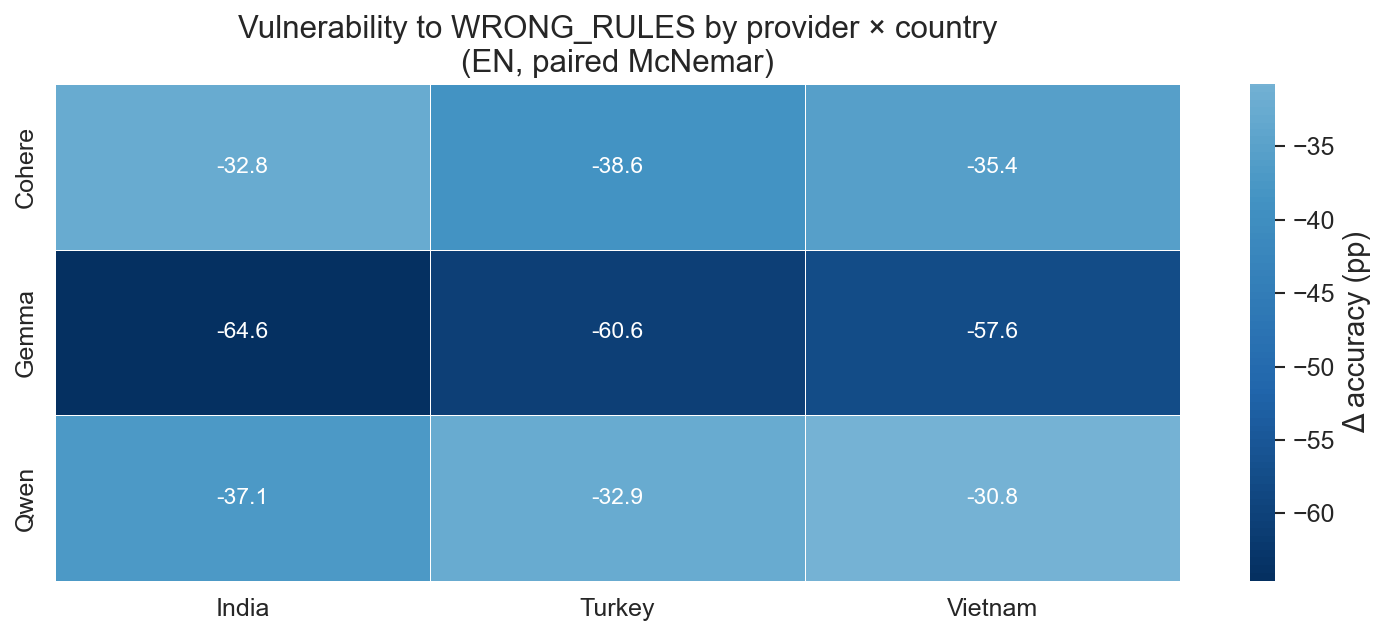

In [32]:
# 15.2 Country × provider heatmap of accuracy drop under WRONG_RULES
piv = wr_slices.pivot(index="provider", columns="country", values="acc_delta")*100
piv = piv.reindex(columns=COUNTRY_ORDER)
fig, ax = plt.subplots(figsize=(10, 0.8*len(piv)+2))
sns.heatmap(piv, annot=True, annot_kws={"size": 11}, fmt=".1f", cmap="RdBu_r", center=0,
            cbar_kws={"label":"Δ accuracy (pp)"}, linewidths=0.4, ax=ax)
ax.set_title("Vulnerability to WRONG_RULES by provider × country\n(EN, paired McNemar)",
             fontsize=15)
ax.set_xlabel(""); ax.set_ylabel("")
plt.tight_layout(); plt.savefig(PLOTS/"wrongrules_provider_country.pdf", bbox_inches="tight")
plt.savefig(PLOTS/"wrongrules_provider_country.png", bbox_inches="tight"); plt.show(); plt.close()


In [33]:
# 15.3 Per-country language sensitivity, by provider (EN → LOCAL flip rate)
loc_pairs = build_pairs(results, LANGCOND_PAIR_IDX, "lang_condition",
                        "EN", "LOCAL", PAIR_VCOLS,
                        {"context_type":"COUNTRY","conflict_type":"NONE"})
loc_pairs["provider"] = loc_pairs["model"].map(PROVIDER)
loc_slices = summarize_pairs(loc_pairs, ["country","provider"]).sort_values(["country","flip_rate"])
loc_slices["p_holm"] = holm(loc_slices["mcnemar_p"].values)
loc_slices["sig"]    = loc_slices["p_holm"] < 0.05
print("=== EN → LOCAL flip-rate / accuracy delta by country × provider ===")
with pd.option_context("display.float_format", lambda x: f"{x:.3f}",
                       "display.max_colwidth", 28, "display.width", 140):
    print(loc_slices[["country","provider","n_pairs","flip_rate",
                       "acc_delta","p_holm","sig"]].to_string(index=False))

=== EN → LOCAL flip-rate / accuracy delta by country × provider ===
country provider  n_pairs  flip_rate  acc_delta  p_holm   sig
  India    Gemma   58.000      0.017      0.000   1.000 False
  India   Cohere  116.000      0.095      0.069   0.070 False
  India     Qwen  116.000      0.181     -0.069   0.615 False
 Turkey    Gemma   70.000      0.086      0.057   0.875 False
 Turkey   Cohere  140.000      0.150      0.014   1.000 False
 Turkey     Qwen  140.000      0.250     -0.021   1.000 False
Vietnam    Gemma   71.000      0.042      0.042   1.000 False
Vietnam   Cohere  144.000      0.090     -0.028   1.000 False
Vietnam     Qwen  144.000      0.132     -0.014   1.000 False


## 16. Save Extended Outputs

Persist the new tables to `analysis_outputs_phase3/` so they can be cited
directly from the paper / appendix.

In [34]:
# 16.1 Extra Excel sheets (extends the file written in section 9)
extra_path = OUT/"phase3_results_sheet.xlsx"
mode = "a" if extra_path.exists() else "w"
kwargs = {"engine":"openpyxl"} | ({"if_sheet_exists":"replace"} if mode=="a" else {})
with pd.ExcelWriter(extra_path, mode=mode, **kwargs) as w:
    (prov_table*100).round(1).to_excel(w, sheet_name="Provider × Country")
    scale_overall.assign(accuracy=lambda d: (d["accuracy"]*100).round(1)).to_excel(
        w, sheet_name="Qwen Scaling Overall", index=False)
    scale_country.assign(accuracy=lambda d: (d["accuracy"]*100).round(1)).to_excel(
        w, sheet_name="Qwen Scaling by Country", index=False)
    sig_all.to_excel(w, sheet_name="Holm Significance", index=False)
    wr_slices.to_excel(w, sheet_name="WRONG_RULES Slices", index=False)
    loc_slices.to_excel(w, sheet_name="EN→LOCAL Slices", index=False)
print(f"Updated {extra_path}")
print("Plots written to:", PLOTS)

Updated ./final_analysis/final_analysis_outputs/phase3_results_sheet.xlsx
Plots written to: ./final_analysis/final_analysis_outputs/plots


In [35]:
# 16.2 One-line takeaways
print("="*70)
print("EXTENDED FINDINGS")
print("="*70)
top_prov = prov_table.sort_values("Overall", ascending=False).index[0]
print(f"• Best provider overall: {top_prov} ({prov_table.loc[top_prov,'Overall']*100:.1f}%)")
print(f"• Qwen size scaling: 0.8B={scale_overall.iloc[0].accuracy*100:.1f}% → "
      f"9B={scale_overall.iloc[-1].accuracy*100:.1f}% "
      f"(Δ={(scale_overall.iloc[-1].accuracy-scale_overall.iloc[0].accuracy)*100:+.1f}pp)")
sig_count = int(sig_all["sig"].sum())
print(f"• {sig_count}/{len(sig_all)} pre-registered comparisons survive Holm at α=0.05")
worst = sig_all.sort_values("acc_delta").iloc[0]
print(f"• Largest harmful effect: {worst['family']} / {worst['comparison']} "
      f"({worst['acc_delta']*100:+.1f}pp, p_holm={worst['p_holm']:.1e})")
best = sig_all.sort_values("acc_delta", ascending=False).iloc[0]
print(f"• Largest beneficial effect: {best['family']} / {best['comparison']} "
      f"({best['acc_delta']*100:+.1f}pp, p_holm={best['p_holm']:.1e})")
print("="*70)

EXTENDED FINDINGS
• Best provider overall: Gemma (59.8%)
• Qwen size scaling: 0.8B=45.3% → 9B=59.5% (Δ=+14.2pp)
• 6/15 pre-registered comparisons survive Holm at α=0.05
• Largest harmful effect: Context/Conflict / Rules → Wrong rules (-39.3pp, p_holm=4.7e-70)
• Largest beneficial effect: Context/Conflict / Country → Rules (+26.9pp, p_holm=8.9e-56)


Generating publication-quality figures for ICML 2026 …

  [1/8] Accuracy heatmap …


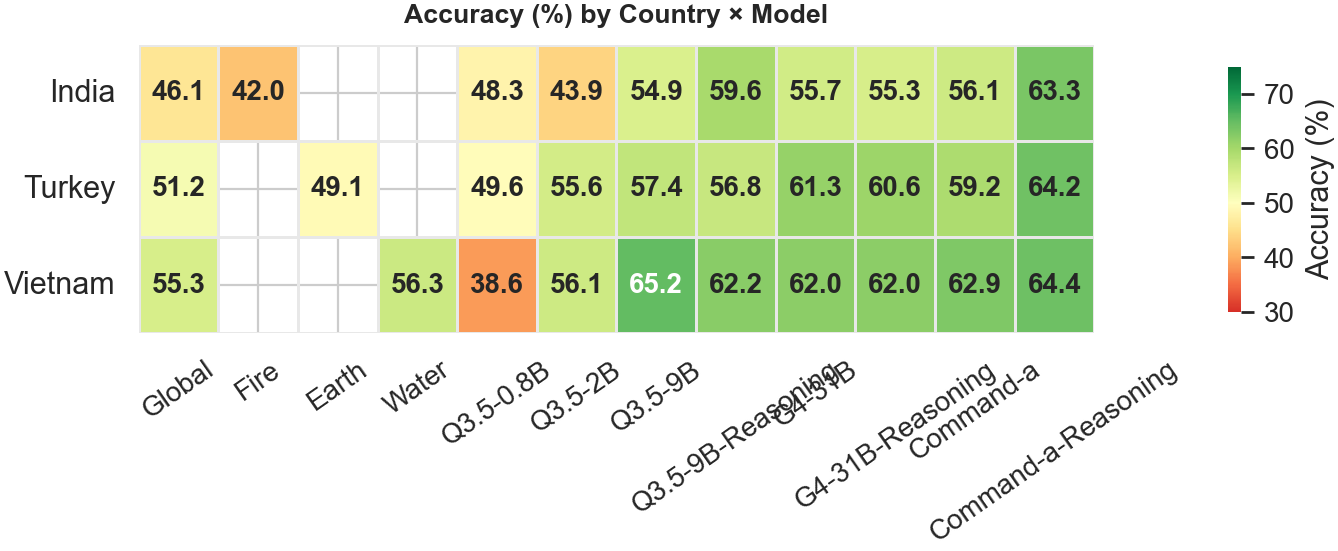

  [2/8] Reasoning slope chart …


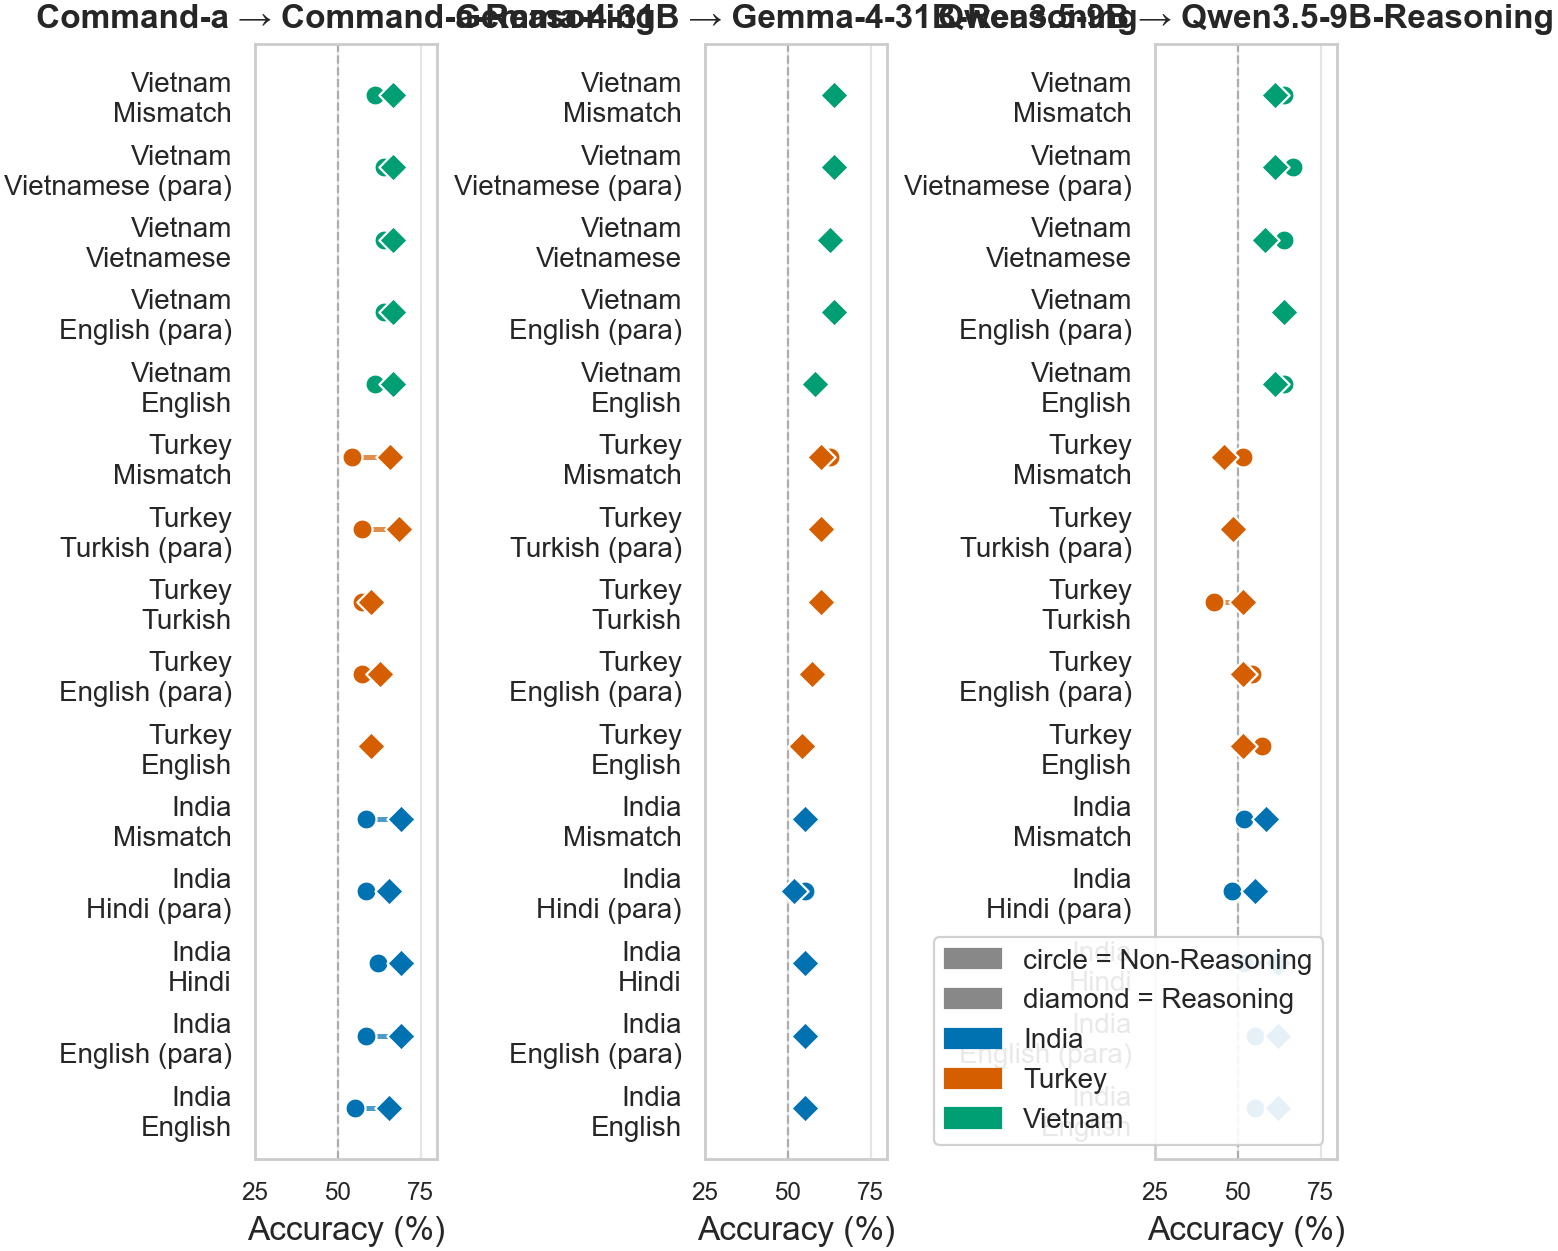

  [3/8] Context/conflict delta lollipop …


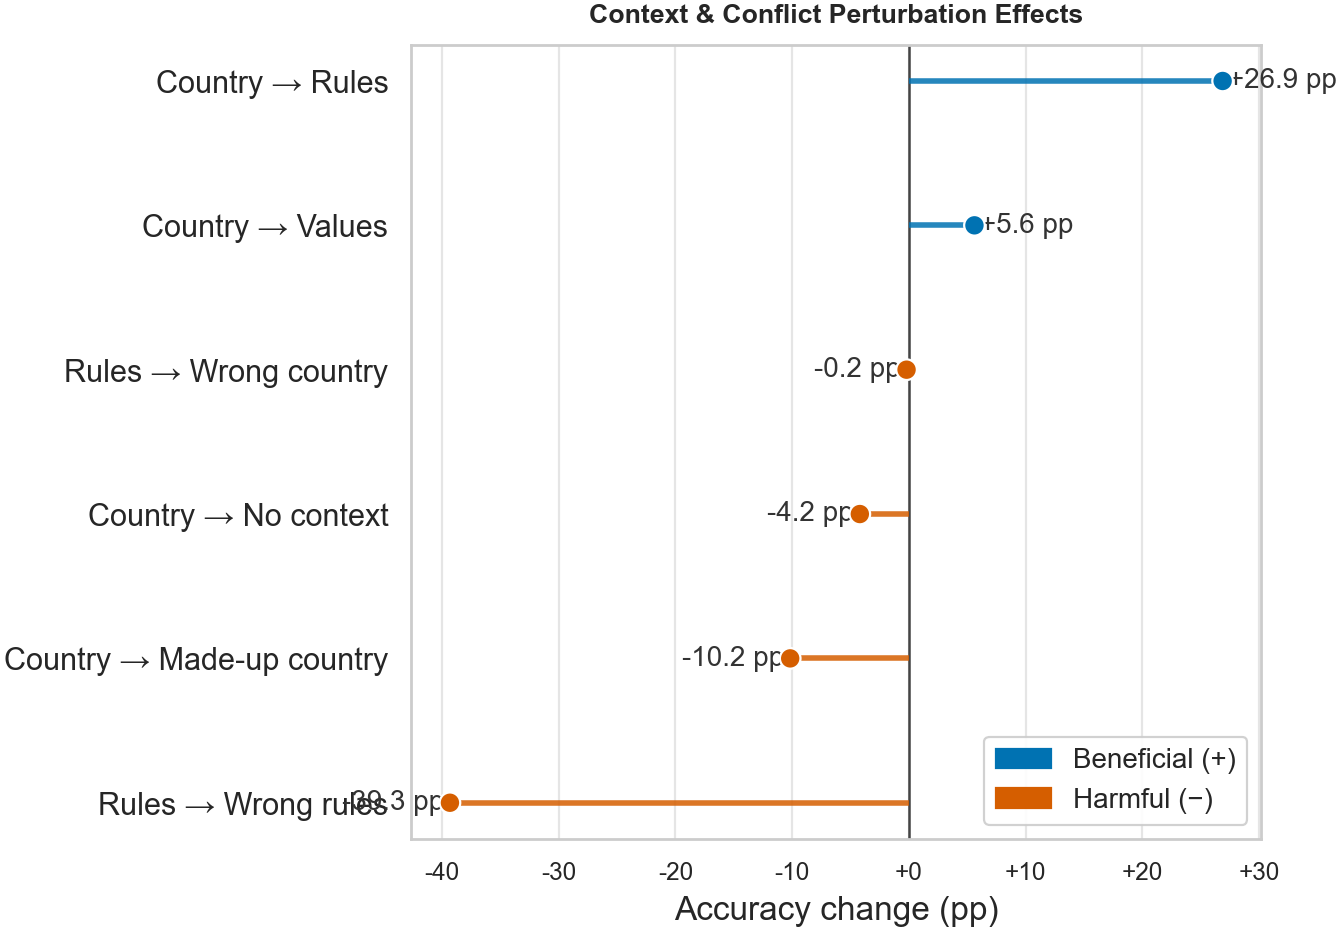

  [4/8] Provider × country grouped bar …


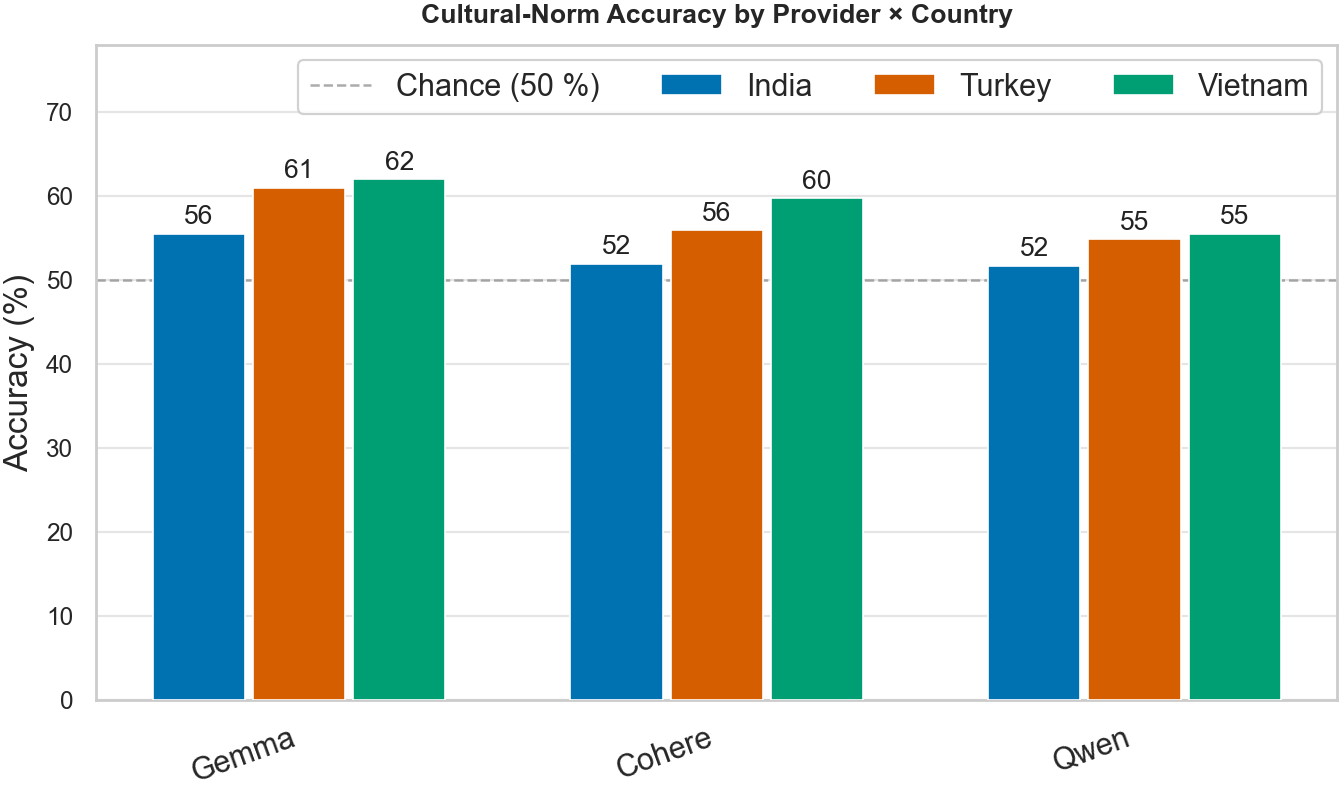

  [5/8] Qwen3.5 scaling …


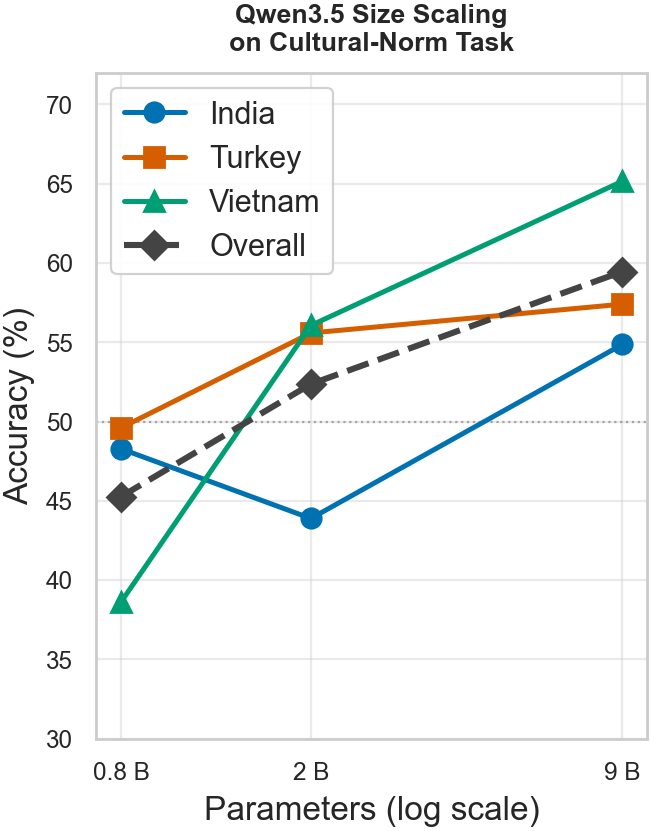

  [6/8] Forest / significance plot …


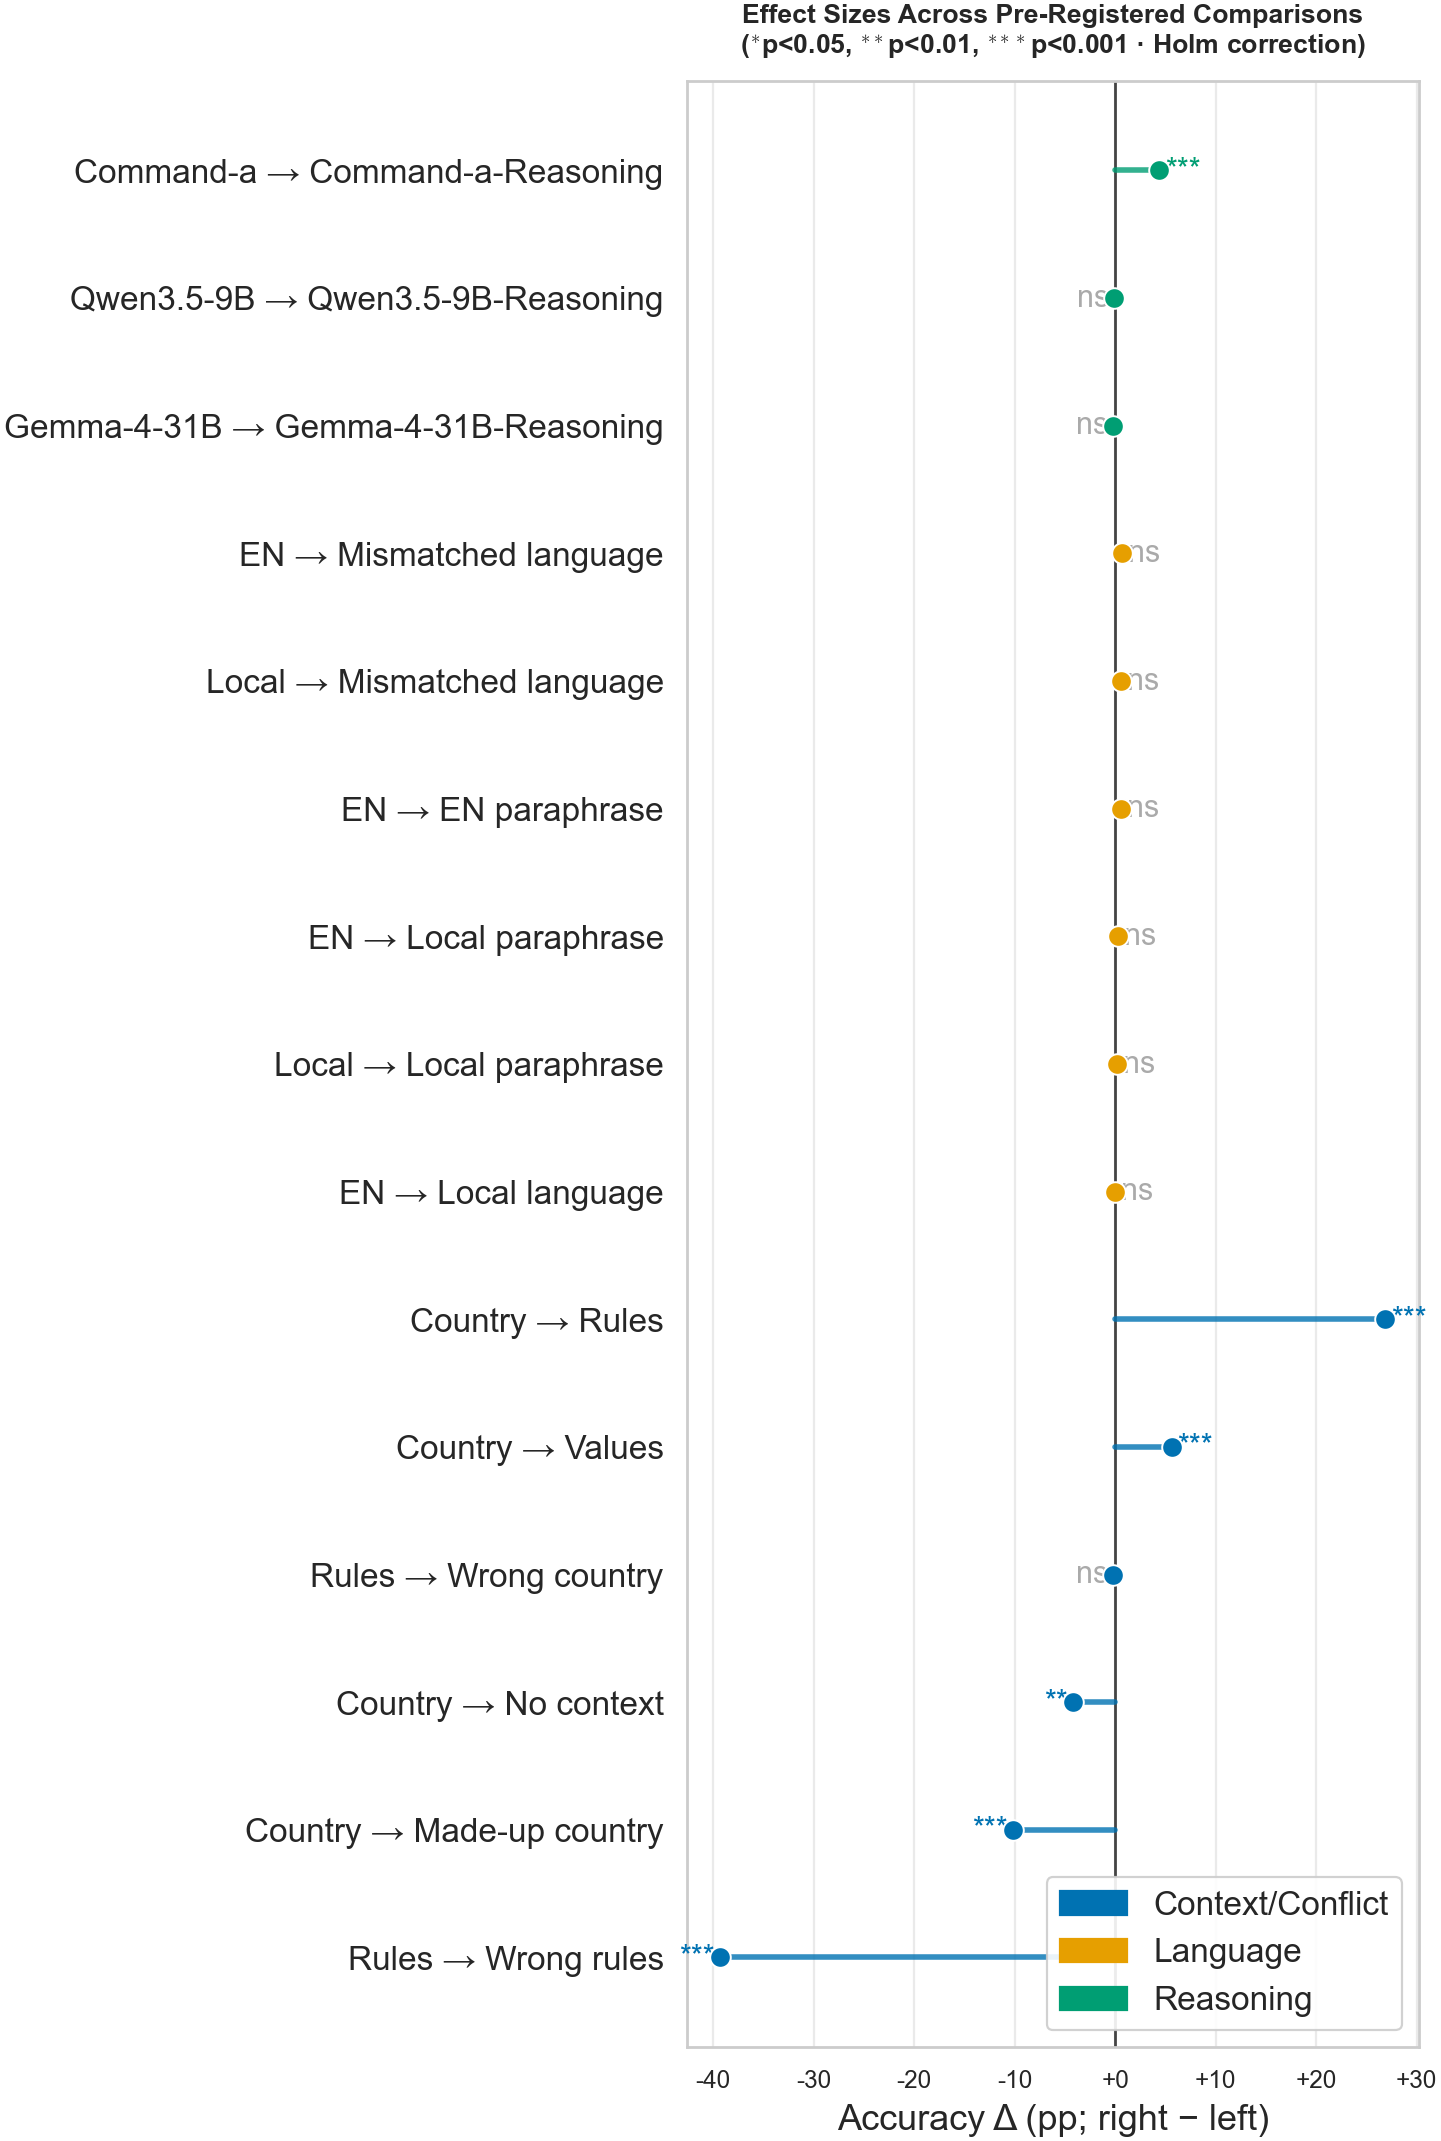

  [7/8] Conflict vulnerability heatmap …


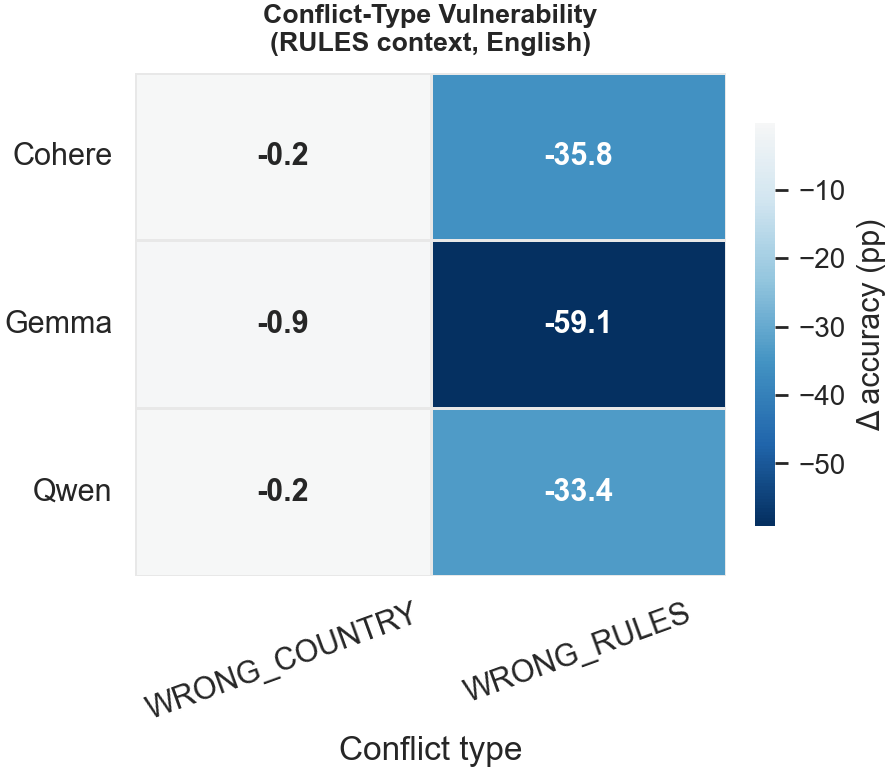

  [8/8] WRONG_RULES provider × country heatmap …


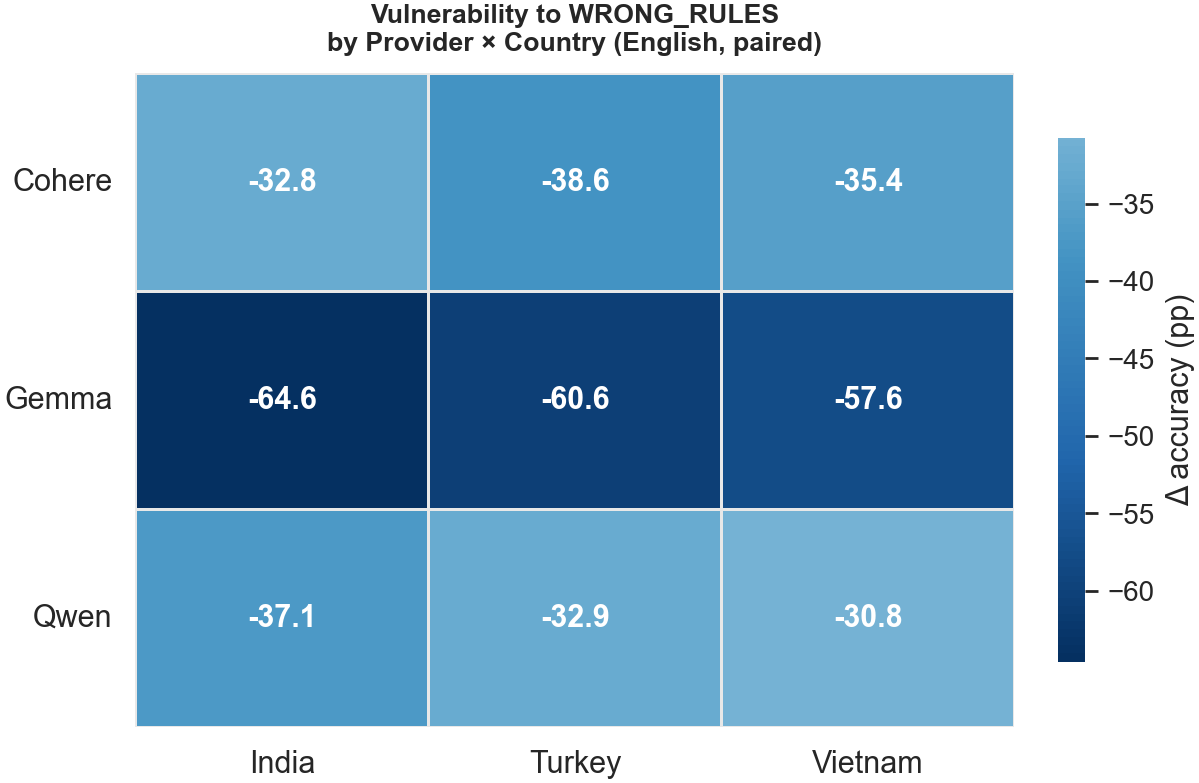


Done — PDF + PNG written to ./final_analysis/final_analysis_outputs/plots/
All figures target ICML 2026 two-column layout (6.75″ full-width).


In [36]:
import importlib, icml_plots
importlib.reload(icml_plots)
icml_plots.generate_all(
    results=results,
    raw_runs=raw_runs,
    acc_overall=acc_overall,
    acc_by_cond=acc_by_cond,
    acc_hm=acc_hm,
    acc_mc=acc_mc,
    lang_pairs=lang_pairs,
    lang_summary=lang_summary,
    reason_pairs=reason_pairs,
    reason_summary=reason_summary,
    cond_summary=cond_summary,
    sig_all=sig_all,
    wr_slices=wr_slices,
    prov_long=prov_long,
    prov_table=prov_table,
    scale_overall=scale_overall,
    scale_country=scale_country,
    qwen_flip=qwen_flip,
    PLOTS=PLOTS,
    # constants from analysis_helpers:
    MODEL_ORDER=MODEL_ORDER,
    COUNTRY_ORDER=COUNTRY_ORDER,
    LANG_CONDITION_ORDER=LANG_CONDITION_ORDER,
    REASONING_PAIRS=REASONING_PAIRS,
    COUNTRY_LOCAL_LANG=COUNTRY_LOCAL_LANG,
)
